**[Source]** Jisoo Project (`지수프젝/1_EDA_v3.ipynb`, 원본 SHA256 앞 16자리 `b93ced0cbd66d1a5`)
**[Status]** FIXED
**[Role]** EDA 기준본 (원본 JSON 구조·분포·품질 확인)
**[Modification]** 원본 코드 수정 금지. 이 파일은 원본의 복사본이며 **맨 위에 이 안내 셀 1개만 추가**했다(코드·출력 셀은 원본과 동일, config/fixed_manifest.json의 code_sha256으로 확인).
**[Rerun]** 재실행하지 않는다. 이미 실행된 결과(`data/preprocessed_final`)를 05번 노트북에서 독립 검증한 뒤 사용한다.

# NIKL 맞춤법 교정 말뭉치 2022 - 탐색적 데이터 분석(EDA)

**대상 파일**: `MXEC2202210100.json` (국립국어원 맞춤법 교정 말뭉치 2022 v1.0, 517MB, 발화 1,129,363건)

이 노트북은 모델링(전처리/학습) 이전에 데이터 자체를 이해하기 위한 EDA용입니다. 아래 순서로 진행합니다.

1. 517MB JSON 파일을 스트리밍으로 읽으면서 발화 단위 통계(길이, 교정 여부, 수정 유형)와 대화(문서) 단위 통계(주제/플랫폼/화자 인구통계)를 동시에 계산
2. `form`과 `corrected_form`의 문자열 유사도를 포함한 텍스트 비교 지표를 전체 발화에 대해 계산
3. 인구통계·주제·플랫폼 분포, 발화 길이 분포, 교정 여부/유형 분포, 유사도 분포 등을 시각화
4. (5장) `form`/`corrected_form` 텍스트를 다시 읽어 **corrected_form 품질이 의심되는 사례**를 규칙으로 찾고, 학습 제외 후보 기준을 제안 (원본 JSON·교정문은 수정하지 않고 별도 CSV로만 저장)
5. (6장) 학습/검증/테스트를 **문서 단위**로 나눠야 하는 근거 수치를 계산 (분할 자체는 아직 만들지 않음)

집계·문자열 비교·의심 규칙은 전체 발화에 적용합니다. 5.4의 화면 예시와 5.5의 사람 검토만 표본을 뽑습니다. 예측 기반 변수 중요도는 전체 발화를 문서 단위 학습·검증에 나눠 사용합니다. 상위 10~15개 그래프는 보기 쉽게 줄인 그림이며 전체 빈도는 표나 CSV에 남깁니다.

**주의**: 이 데이터는 문서(대화) 단위로 화자 말투·어휘·맥락이 강하게 반복되는 구조입니다. 나중에 모델 학습용으로 train/valid/test를 나눌 때는 발화 단위가 아니라 **문서(document) 단위**로 분할해야 정보 누수를 막을 수 있습니다 (이 노트북 마지막 셀에 관련 참고 코드가 있습니다).

In [1]:
%matplotlib inline
import os, re, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")

# 한글 폰트 자동 탐색 (없으면 기본 폰트로 진행되며, 이 경우 한글이 깨져 보일 수 있습니다)
for _cand in ["Noto Sans CJK KR", "Noto Sans CJK JP", "Noto Sans CJK SC", "NanumGothic", "Malgun Gothic", "AppleGothic"]:
    if any(f.name == _cand for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _cand
        break
plt.rcParams["axes.unicode_minus"] = False

# 색상 팔레트: 범주형은 고정 순서 8색, 크기(magnitude) 비교에는 단일 색조(블루) 사용
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK_SECOND, INK_MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECOND, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

# 데이터 경로: 이 노트북과 같은 폴더에 데이터 폴더가 있다고 가정한 상대경로입니다.
# 다른 위치에서 실행한다면 아래 경로를 직접 수정하세요.
DATA_PATH = os.environ.get(
    "NIKL_DATA_PATH",
    "data/MXEC2202210100.json",
)
print("데이터 경로:", DATA_PATH)
print("파일 존재 여부:", os.path.exists(DATA_PATH))


데이터 경로: data/MXEC2202210100.json
파일 존재 여부: True


## 1. 데이터 파싱

파일이 517MB로 크기 때문에 `json.load`로 한 번에 메모리에 올리지 않고, 한 줄씩 읽으며 필요한 필드만 정규식으로 추출합니다.
(외부 라이브러리 설치 없이 표준 라이브러리만으로 동작하도록 작성했습니다. `ijson` 등이 설치돼 있다면 더 견고한 방식으로 바꿔도 됩니다.)

- 발화(utterance) 단위 통계는 **전체 1,129,363건**을 대상으로 계산합니다.
- `form`과 `corrected_form` 사이의 문자열 유사도(`difflib`)도 **전체 발화**에 대해 계산합니다. 표본 계산보다 실행 시간이 길어집니다.


In [2]:
import difflib, time, json

PUNCT_CHARS = set(".,!?~…·\"\'()[]{}:;-/\\")

def _nospace(s):
    return "".join(s.split())

def _nospace_nopunct(s):
    return "".join(ch for ch in s if not ch.isspace() and ch not in PUNCT_CHARS)

def parse_corpus(path):
    """
    발화 단위 DataFrame(df), 전체 발화 유사도 DataFrame(df_similarity),
    문서별 발화 수(doc_utt_count), 이모티콘/무의미어 값 빈도(Counter)를 반환합니다.
    """
    id_re = re.compile(r'"id":\s*"([^"]+)"')
    topic_re = re.compile(r'"topic":\s*"([^"]*)"')
    publisher_re = re.compile(r'"publisher":\s*"([^"]*)"')
    relation_re = re.compile(r'"relation":\s*"([^"]*)"')
    speaker_id_re = re.compile(r'"speaker_id":\s*"([^"]*)"')
    sex_re = re.compile(r'"sex":\s*"([^"]*)"')
    age_re = re.compile(r'"age":\s*"([^"]*)"')
    form_re = re.compile(r'"form":\s*"(.*)",?$')
    corrected_re = re.compile(r'"corrected_form":\s*"(.*)",?$')
    value_re = re.compile(r'"value":\s*"(.*)",?$')

    rows, similarity_rows = [], []
    doc_utt_count = Counter()
    emoticon_values, meaningless_values = Counter(), Counter()

    _intern = {}
    def intern(s):
        if s is None:
            return None
        return _intern.setdefault(s, s)

    cur_topic = cur_publisher = cur_relation = cur_doc_id = None
    cur_speakers, cur_speaker_id = {}, None
    cur_form = cur_corrected = None
    cur_form_missing = cur_corrected_missing = False
    in_emoticon = in_meaningless = False
    utt_counter = n_lines = 0
    t0 = time.time()

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            n_lines += 1
            s = line.strip()

            if s.startswith('"id":'):
                m = id_re.search(s)
                if m:
                    val = m.group(1)
                    if val.count(".") == 1:
                        cur_doc_id = intern(val)
                        cur_speakers = {}
                    elif val.isdigit():
                        cur_speaker_id = val
            elif s.startswith('"topic":'):
                m = topic_re.search(s); cur_topic = intern(m.group(1)) if m else None
            elif s.startswith('"publisher":'):
                m = publisher_re.search(s); cur_publisher = intern(m.group(1)) if m else None
            elif s.startswith('"relation":'):
                m = relation_re.search(s); cur_relation = intern(m.group(1)) if m else None
            elif s.startswith('"sex":'):
                m = sex_re.search(s)
                if m and cur_speaker_id is not None:
                    cur_speakers.setdefault(cur_speaker_id, {})["sex"] = intern(m.group(1))
            elif s.startswith('"age":'):
                m = age_re.search(s)
                if m and cur_speaker_id is not None:
                    cur_speakers.setdefault(cur_speaker_id, {})["age"] = intern(m.group(1))
            elif s.startswith('"form":'):
                m = form_re.search(s); cur_form = json.loads('"' + m.group(1) + '"') if m else ""
                cur_form_missing = (m is None)
            elif s.startswith('"corrected_form":'):
                m = corrected_re.search(s); cur_corrected = json.loads('"' + m.group(1) + '"') if m else ""
                cur_corrected_missing = (m is None)
            elif s.startswith('"speaker_id":'):
                m = speaker_id_re.search(s)
                spk = m.group(1) if m else None
                utt_counter += 1
                if cur_doc_id:
                    doc_utt_count[cur_doc_id] += 1

                changed = (cur_form != cur_corrected)
                if not changed:
                    edit_type = 0
                else:
                    f_ns, c_ns = _nospace(cur_form or ""), _nospace(cur_corrected or "")
                    if f_ns == c_ns:
                        edit_type = 1
                    else:
                        f_np = _nospace_nopunct(cur_form or "")
                        c_np = _nospace_nopunct(cur_corrected or "")
                        edit_type = 2 if f_np == c_np else 3

                spk_info = cur_speakers.get(spk, {})
                rows.append((
                    cur_doc_id, intern(spk), cur_topic, cur_publisher, cur_relation,
                    spk_info.get("sex"), spk_info.get("age"),
                    len(cur_form or ""), len(cur_corrected or ""),
                    changed, edit_type,
                    cur_form_missing, (cur_form == ""),
                    cur_corrected_missing, (cur_corrected == ""),
                ))
                ratio = 1.0 if cur_form == cur_corrected else difflib.SequenceMatcher(None, cur_form or "", cur_corrected or "").ratio()
                valid_pair = bool((cur_form or "").strip() and (cur_corrected or "").strip())
                similarity_rows.append((cur_doc_id, cur_topic, len(cur_form or ""), ratio, valid_pair))
            elif '"emoticon": [' in s:
                in_emoticon = not s.rstrip(",").endswith("[]")
            elif in_emoticon:
                if s.startswith("]"):
                    in_emoticon = False
                else:
                    vm = value_re.search(s)
                    if vm:
                        emoticon_values[json.loads('"' + vm.group(1) + '"')] += 1
            elif '"meaningless_words": [' in s:
                in_meaningless = not s.rstrip(",").endswith("[]")
            elif in_meaningless:
                if s.startswith("]"):
                    in_meaningless = False
                else:
                    vm = value_re.search(s)
                    if vm:
                        meaningless_values[json.loads('"' + vm.group(1) + '"')] += 1

            if n_lines % 3_000_000 == 0:
                print(f"  ... {n_lines:,}줄 처리 ({time.time()-t0:.0f}s 경과)")

    df = pd.DataFrame(rows, columns=[
        "doc_id", "speaker_id", "topic", "publisher", "relation", "sex", "age",
        "len_form", "len_corrected", "changed", "edit_type",
        "form_missing", "form_empty", "corrected_form_missing", "corrected_form_empty",
    ])
    df_similarity = pd.DataFrame(similarity_rows, columns=["doc_id", "topic", "len_form", "similarity", "valid"])
    print(f"파싱 완료: {time.time()-t0:.1f}s 소요")
    return df, df_similarity, doc_utt_count, emoticon_values, meaningless_values


print("파싱 시작 (파일 크기 때문에 30초~2분 정도 걸릴 수 있습니다)...")
df, df_similarity, doc_utt_count, emoticon_values, meaningless_values = parse_corpus(DATA_PATH)
print(f"\n발화(utterance) 수: {len(df):,}")
print(f"문서(document) 수: {len(doc_utt_count):,}")
print(f"유사도를 계산한 발화 수: {len(df_similarity):,}")
assert len(df_similarity) == len(df), "일부 발화의 유사도가 계산되지 않았습니다."
df_changed = df["changed"]
print(f"교정 없음(form == corrected_form): {(~df_changed).sum():,} ({(~df_changed).mean()*100:.1f}%)")
print(f"교정 있음(form != corrected_form): {df_changed.sum():,} ({df_changed.mean()*100:.1f}%)")


파싱 시작 (파일 크기 때문에 30초~2분 정도 걸릴 수 있습니다)...
  ... 3,000,000줄 처리 (8s 경과)
  ... 6,000,000줄 처리 (17s 경과)
  ... 9,000,000줄 처리 (25s 경과)
파싱 완료: 31.5s 소요

발화(utterance) 수: 1,129,363
문서(document) 수: 21,335
유사도를 계산한 발화 수: 1,129,363
교정 없음(form == corrected_form): 173,769 (15.4%)
교정 있음(form != corrected_form): 955,594 (84.6%)


### 1.1 필드 완전성 및 교정 전후 길이 차이

두 길이 분포가 다르다는 사실만으로 결측을 의미하지는 않습니다. 교정 과정에서 띄어쓰기와 문장부호가 추가되거나 삭제되면 모든 값이 존재해도 두 분포는 달라집니다.

아래 첫 번째 표는 `필드 자체가 없음`, `필드는 있지만 빈 문자열`, `사용 가능한 값`을 구분합니다. 두 번째 표는 `corrected_form`이 `form`보다 길어진 발화, 짧아진 발화, 길이가 같은 발화의 개수를 보여줍니다.

현재 파일 전수 검사 결과, `topic`·`publisher`·`relation`·`sex`·`age`는 누락과 빈 문자열이 모두 0건입니다. `form`은 빈 문자열 22,915건, `corrected_form`은 빈 문자열 21,722건이며 두 필드 모두 키 자체가 누락된 발화는 없습니다. (원본에는 `{share:photo}`처럼 사진/이모지 공유 메시지가 제거되면서 `form`과 `corrected_form`이 빈 문자열이 되는 사례가 다수 있습니다.) 아래 코드를 다시 실행하면 원본 데이터 기준으로 표가 자동 갱신됩니다.


In [3]:
# 주요 분석 필드의 결측·빈 문자열·정상값 현황
FIELD_LABELS = {
    "topic": "대화 주제",
    "publisher": "플랫폼",
    "relation": "화자 관계",
    "sex": "성별",
    "age": "연령대",
    "form": "form(원문 정제본)",
    "corrected_form": "corrected_form(교정본)",
}

completeness_rows = []
total_rows = len(df)

for field in ["topic", "publisher", "relation", "sex", "age"]:
    missing_count = int(df[field].isna().sum())
    empty_count = int(df[field].fillna("").astype(str).str.strip().eq("").sum() - missing_count)
    available_count = total_rows - missing_count - empty_count
    completeness_rows.append({
        "필드": FIELD_LABELS[field],
        "전체": total_rows,
        "필드 누락": missing_count,
        "빈 문자열": empty_count,
        "사용 가능": available_count,
        "사용 불가율(%)": (missing_count + empty_count) / total_rows * 100,
    })

for field, parsed_prefix in [("form", "form"), ("corrected_form", "corrected_form")]:
    missing_count = int(df[f"{parsed_prefix}_missing"].sum())
    empty_count = int((df[f"{parsed_prefix}_empty"] & ~df[f"{parsed_prefix}_missing"]).sum())
    available_count = total_rows - missing_count - empty_count
    completeness_rows.append({
        "필드": FIELD_LABELS[field],
        "전체": total_rows,
        "필드 누락": missing_count,
        "빈 문자열": empty_count,
        "사용 가능": available_count,
        "사용 불가율(%)": (missing_count + empty_count) / total_rows * 100,
    })

completeness_df = pd.DataFrame(completeness_rows)
try:
    display(
        completeness_df.style
        .format({
            "전체": "{:,}", "필드 누락": "{:,}", "빈 문자열": "{:,}",
            "사용 가능": "{:,}", "사용 불가율(%)": "{:.4f}",
        })
        .background_gradient(subset=["사용 불가율(%)"], cmap="Reds")
    )
except (ImportError, AttributeError):
    # 이 실행 환경의 jinja2 버전이 pandas Styler 요구사항보다 낮아 스타일링을 건너뜁니다.
    display(completeness_df.round(4))

# 그래프의 차이가 결측이 아니라 실제 교정 길이 변화 때문인지 확인
length_delta = df["len_corrected"] - df["len_form"]
length_change_df = pd.DataFrame({
    "구분": [
        "교정본이 더 짧음",
        "길이 동일",
        "교정본이 더 김",
    ],
    "발화 수": [
        int((length_delta < 0).sum()),
        int((length_delta == 0).sum()),
        int((length_delta > 0).sum()),
    ],
})
length_change_df["비율(%)"] = length_change_df["발화 수"] / total_rows * 100
try:
    display(length_change_df.style.format({"발화 수": "{:,}", "비율(%)": "{:.2f}"}))
except (ImportError, AttributeError):
    display(length_change_df.round(2))

print(f"교정 후 총 문자 수 증감: {int(length_delta.sum()):+,}자")
print(f"발화당 평균 문자 수 증감: {length_delta.mean():+.3f}자")


,필드,전체,필드 누락,빈 문자열,사용 가능,사용 불가율(%)
0,대화 주제,"1,129,363",0,0,"1,129,363",0.0000
1,플랫폼,"1,129,363",0,0,"1,129,363",0.0000
2,화자 관계,"1,129,363",0,0,"1,129,363",0.0000
3,성별,"1,129,363",0,0,"1,129,363",0.0000
4,연령대,"1,129,363",0,0,"1,129,363",0.0000
5,form(원문 정제본),"1,129,363",0,"22,915","1,106,448",2.0290
6,corrected_form(교정본),"1,129,363",0,"21,722","1,107,641",1.9234


,구분,발화 수,비율(%)
0,교정본이 더 짧음,"57,424",5.08
1,길이 동일,"223,356",19.78
2,교정본이 더 김,"848,583",75.14


교정 후 총 문자 수 증감: +1,716,068자
발화당 평균 문자 수 증감: +1.520자


In [4]:
# form과 corrected_form이 둘 다 빈 문자열인 경우, changed=False(교정 없음)로 집계되어
# "교정이 필요 없던 정상 문장"과 뒤섞입니다. 실제로 얼마나 섞여 있는지 확인합니다.
both_empty = df["form_empty"] & df["corrected_form_empty"]
n_both_empty = int(both_empty.sum())
n_unchanged = int((~df["changed"]).sum())

print(f"form과 corrected_form이 둘 다 빈 문자열인 발화: {n_both_empty:,}건")
print(f"이 중 '교정 없음(changed=False)'으로 집계된 발화: {int((both_empty & ~df['changed']).sum()):,}건")
print(f"기존 '교정 없음' {n_unchanged:,}건 중 실제로는 {n_both_empty/n_unchanged*100:.1f}%가 빈 발화(공유 메시지 등 제거 흔적)입니다.")
print(f"빈 발화를 제외한 진짜 '수정 불필요' 발화 수: {n_unchanged - n_both_empty:,}건")


form과 corrected_form이 둘 다 빈 문자열인 발화: 21,371건
이 중 '교정 없음(changed=False)'으로 집계된 발화: 21,371건
기존 '교정 없음' 173,769건 중 실제로는 12.3%가 빈 발화(공유 메시지 등 제거 흔적)입니다.
빈 발화를 제외한 진짜 '수정 불필요' 발화 수: 152,398건


## 2. 대화·발화 분포

**중요한 구분**: 아래 분포는 대화(문서), 대화별 발화한 화자, 발화(utterance)를 구별합니다. 한 대화에 여러 화자가 있으므로 성별·연령대를 대화 하나당 하나의 값으로 셀 수 없습니다. 화자 구성은 (문서 ID, 화자 ID) 조합을 한 번씩 세고, 발화 기준 수치는 말이 많은 화자의 영향까지 함께 보려고 표에 표시합니다. 모델 학습 샘플 수는 발화 기준입니다.


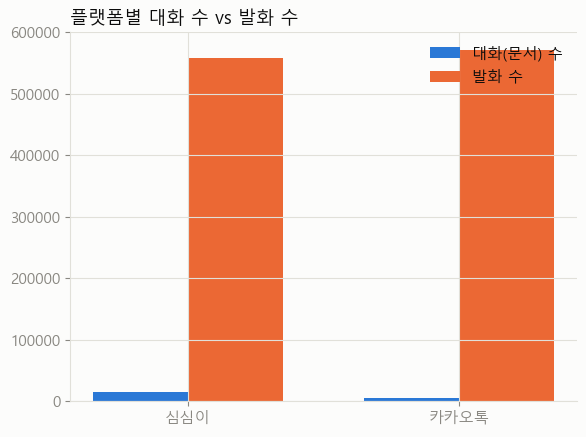

대화당 평균 발화 수:
publisher
심심이     36.4
카카오톡    95.3
Name: count, dtype: float64


In [5]:
doc_level = df.drop_duplicates("doc_id")
pub_doc = doc_level["publisher"].value_counts()
pub_utt = df["publisher"].value_counts()

platforms = sorted(set(pub_doc.index) | set(pub_utt.index))
x = np.arange(len(platforms))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(x - width/2, [pub_doc.get(p, 0) for p in platforms], width, label="대화(문서) 수", color=CAT[0])
ax.bar(x + width/2, [pub_utt.get(p, 0) for p in platforms], width, label="발화 수", color=CAT[1])
ax.set_xticks(x)
ax.set_xticklabels(platforms)
ax.set_title("플랫폼별 대화 수 vs 발화 수", fontsize=13, color=INK, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("대화당 평균 발화 수:")
print((pub_utt / pub_doc).round(1))


[전체 주제별 발화 수]


,발화 수
topic,
기타/일상,363163
식음료,154278
쇼핑과 상품,66700
콘텐츠>영상/음원 콘텐츠,61445
가사 및 가족,51137
...,...
"일상 트렌드>ESG(친환경, 사회, 지배구조) 활동",36
"시사(정치, 경제, 사회)>플랫폼 국감",35
"시사(정치, 경제, 사회)>애플 신제품 공개",31


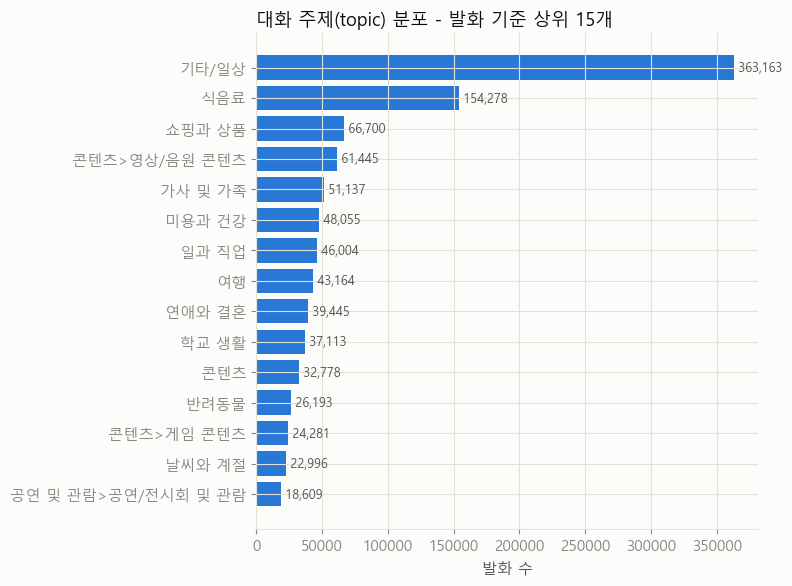

In [6]:
topic_counts_full = df["topic"].value_counts()
print("[전체 주제별 발화 수]")
display(topic_counts_full.rename("발화 수").to_frame())
topic_counts = topic_counts_full.head(15).sort_values()  # 그림만 상위 15개

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(topic_counts.index, topic_counts.values, color=CAT[0])
ax.set_title("대화 주제(topic) 분포 - 발화 기준 상위 15개", fontsize=13, color=INK, loc="left")
ax.set_xlabel("발화 수")
for y, v in enumerate(topic_counts.values):
    ax.text(v, y, f" {v:,}", va="center", fontsize=9, color=INK_SECOND)
plt.tight_layout()
plt.show()


[전체 관계별 대화 수]


,대화 수
relation,
낯선 사람,12171
학교/학원>동기/동창/동급생,3259
기타>연인,903
가족>부부,883
가족>형제자매,721
기타>그 외 사회적 관계,592
기타>온라인 커뮤니티,569
지역>고향 및 이전 거주지 지인,555
지역>현 거주지 지인,505


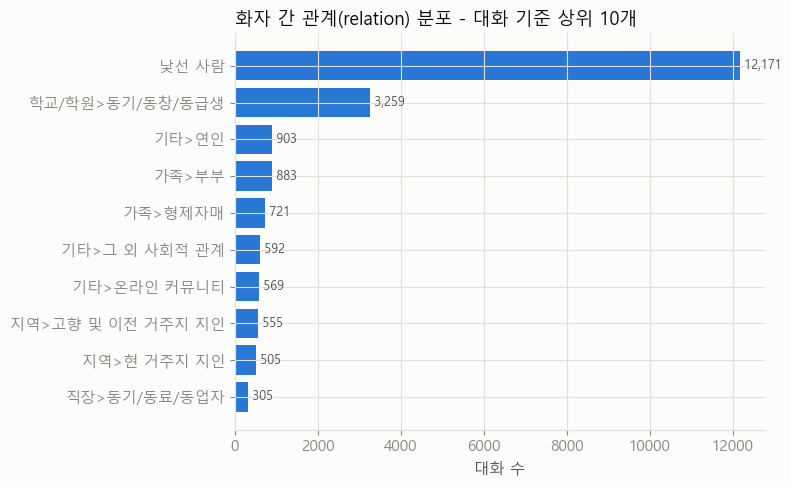

In [7]:
rel_counts_full = df.drop_duplicates("doc_id")["relation"].value_counts()
print("[전체 관계별 대화 수]")
display(rel_counts_full.rename("대화 수").to_frame())
rel_counts = rel_counts_full.head(10).sort_values()  # 그림만 상위 10개

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rel_counts.index, rel_counts.values, color=CAT[0])
ax.set_title("화자 간 관계(relation) 분포 - 대화 기준 상위 10개", fontsize=13, color=INK, loc="left")
ax.set_xlabel("대화 수")
for y, v in enumerate(rel_counts.values):
    ax.text(v, y, f" {v:,}", va="center", fontsize=9, color=INK_SECOND)
plt.tight_layout()
plt.show()


,발화한 화자 수,발화 수
sex,,
여성,38299,985084
남성,5135,144279


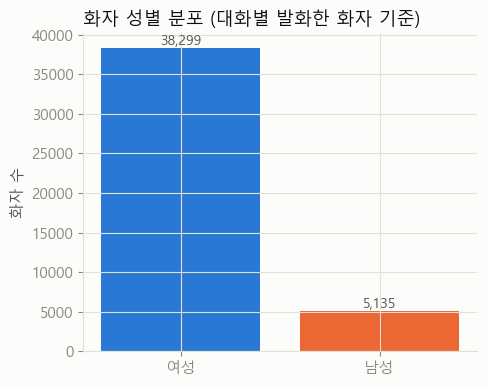

발화한 화자 수 기준 여성/남성 비율: 7.46
※ 발화 기준은 말이 많은 화자의 비중이 커지므로, 화자 구성 설명에는 위 화자 수 기준을 사용합니다.


In [8]:
# 성별은 대화 하나에 여러 화자가 있으므로 '대화의 성별' 하나로 셀 수 없습니다.
# 같은 대화에서 여러 번 말한 사람은 한 번만 세는 화자 기준과 발화 기준을 함께 봅니다.
speaker_level = df.dropna(subset=["doc_id", "speaker_id"]).drop_duplicates(["doc_id", "speaker_id"])
sex_counts = speaker_level["sex"].value_counts()
sex_table = pd.concat([sex_counts.rename("발화한 화자 수"), df["sex"].value_counts().rename("발화 수")], axis=1).fillna(0).astype(int)
display(sex_table)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(sex_counts.index, sex_counts.values, color=CAT[:len(sex_counts)])
for b, v in zip(bars, sex_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontsize=10, color=INK_SECOND)
ax.set_title("화자 성별 분포 (대화별 발화한 화자 기준)", fontsize=13, color=INK, loc="left")
ax.set_ylabel("화자 수")
plt.tight_layout()
plt.show()
print("발화한 화자 수 기준 여성/남성 비율:", round(sex_counts.get("여성", 0) / max(sex_counts.get("남성", 1), 1), 2))
print("※ 발화 기준은 말이 많은 화자의 비중이 커지므로, 화자 구성 설명에는 위 화자 수 기준을 사용합니다.")

,발화한 화자 수,발화 수
age,,
10대,2256,43074
20대,24841,665837
30대,14048,343561
40대 이상,2289,76891


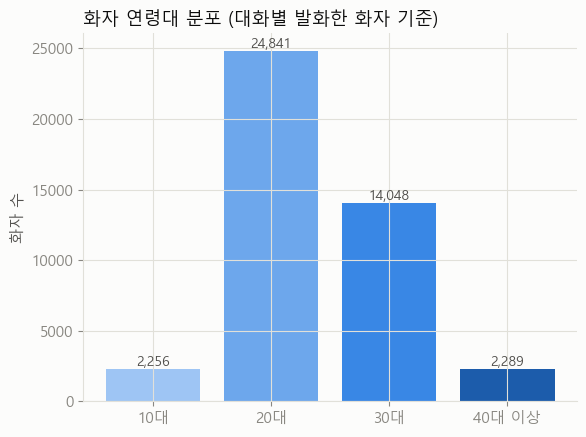

※ 같은 대화에서 여러 번 말한 화자는 한 번만 셉니다. 다른 대화의 화자가 동일인인지 알 수 없어 대화 간에는 합치지 않습니다.


In [9]:
age_order = ["10대", "20대", "30대", "40대 이상"]
age_counts = speaker_level["age"].value_counts().reindex(age_order).fillna(0).astype(int)
age_table = pd.concat([age_counts.rename("발화한 화자 수"), df["age"].value_counts().reindex(age_order).fillna(0).astype(int).rename("발화 수")], axis=1)
display(age_table)
shades = ["#9ec5f4", "#6da7ec", "#3987e5", "#1c5cab"]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(age_counts.index, age_counts.values, color=shades)
for b, v in zip(bars, age_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{int(v):,}", ha="center", va="bottom", fontsize=10, color=INK_SECOND)
ax.set_title("화자 연령대 분포 (대화별 발화한 화자 기준)", fontsize=13, color=INK, loc="left")
ax.set_ylabel("화자 수")
plt.tight_layout()
plt.show()

print("※ 같은 대화에서 여러 번 말한 화자는 한 번만 셉니다. 다른 대화의 화자가 동일인인지 알 수 없어 대화 간에는 합치지 않습니다.")


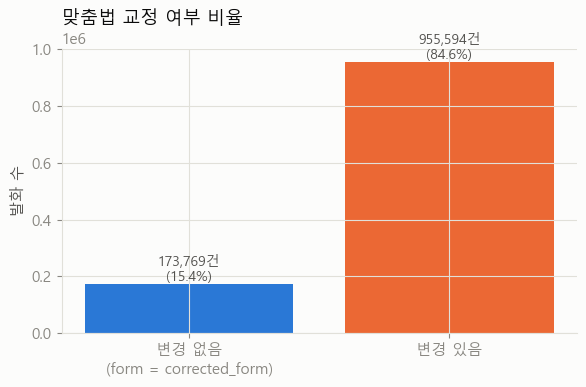

In [10]:
df_changed = df["changed"]
changed_counts = df_changed.value_counts().reindex([False, True])
labels = ["변경 없음\n(form = corrected_form)", "변경 있음"]
values = changed_counts.values
pct = values / values.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=[CAT[0], CAT[1]])
for b, v, p in zip(bars, values, pct):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}건\n({p:.1f}%)", ha="center", va="bottom", fontsize=10, color=INK_SECOND)
ax.set_title("맞춤법 교정 여부 비율", fontsize=13, color=INK, loc="left")
ax.set_ylabel("발화 수")
plt.tight_layout()
plt.show()


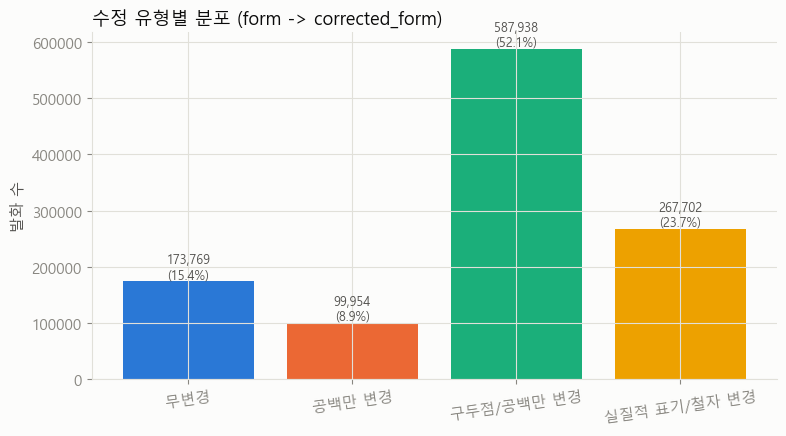

In [11]:
type_labels = {0: "무변경", 1: "공백만 변경", 2: "구두점/공백만 변경", 3: "실질적 표기/철자 변경"}
type_counts = df["edit_type"].map(type_labels).value_counts().reindex(list(type_labels.values()))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(type_counts.index, type_counts.values, color=CAT[:4])
for b, v in zip(bars, type_counts.values):
    pct = v / len(df) * 100
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9, color=INK_SECOND)
ax.set_title("수정 유형별 분포 (form -> corrected_form)", fontsize=13, color=INK, loc="left")
ax.set_ylabel("발화 수")
plt.xticks(rotation=8)
plt.tight_layout()
plt.show()


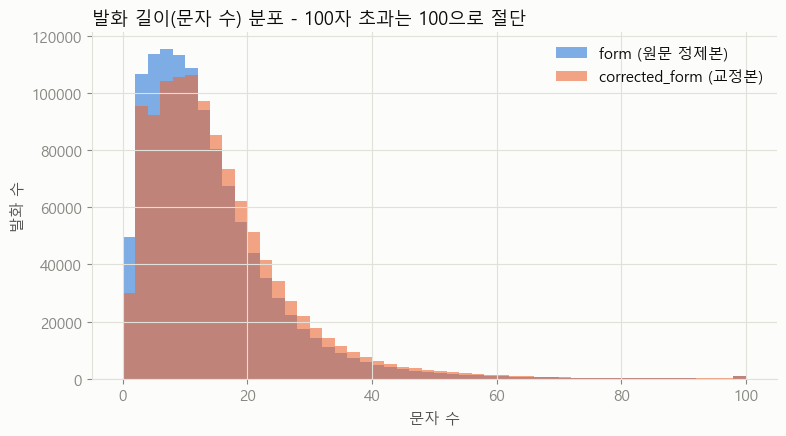


[원문·교정문 빈값 현황: 1.1절과 같은 전수 집계]


,필드,전체,필드 누락,빈 문자열,사용 가능
5,form(원문 정제본),1129363,0,22915,1106448
6,corrected_form(교정본),1129363,0,21722,1107641


둘 다 빈 문자열: 21,371건

[발화 길이 요약: 문자 수]


,count,mean,median,min,max
form,1129363.0,13.2,11.0,0.0,6916.0
corrected_form,1129363.0,14.7,12.0,0.0,6924.0


In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = list(range(0, 102, 2))
ax.hist(df["len_form"].clip(upper=100), bins=bins, alpha=0.6, color=CAT[0], label="form (원문 정제본)")
ax.hist(df["len_corrected"].clip(upper=100), bins=bins, alpha=0.6, color=CAT[1], label="corrected_form (교정본)")
ax.set_title("발화 길이(문자 수) 분포 - 100자 초과는 100으로 절단", fontsize=13, color=INK, loc="left")
ax.set_xlabel("문자 수")
ax.set_ylabel("발화 수")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("\n[원문·교정문 빈값 현황: 1.1절과 같은 전수 집계]")
display(completeness_df.loc[completeness_df["필드"].isin([FIELD_LABELS["form"], FIELD_LABELS["corrected_form"]]), ["필드", "전체", "필드 누락", "빈 문자열", "사용 가능"]])
print(f"둘 다 빈 문자열: {int((df['form_empty'] & df['corrected_form_empty']).sum()):,}건")
print("\n[발화 길이 요약: 문자 수]")
length_table = df[["len_form", "len_corrected"]].agg(["count", "mean", "median", "min", "max"]).T.round(1)
length_table.index = ["form", "corrected_form"]
display(length_table)


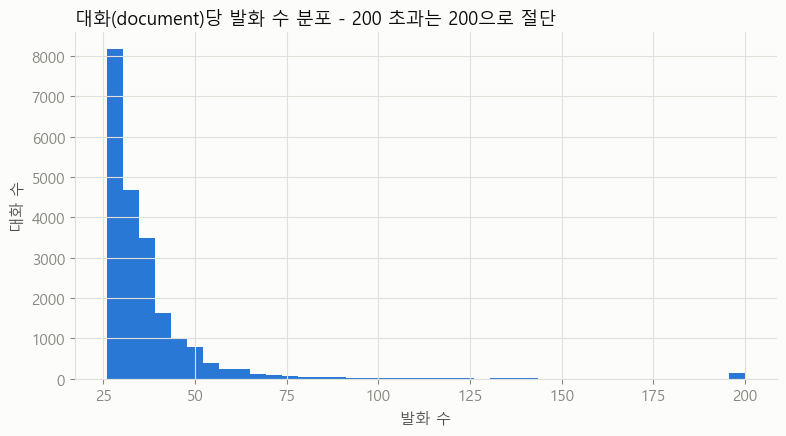

대화당 발화 수 - 평균: 52.9, 중앙값: 32, 최댓값: 7,674


In [13]:
doc_lengths = pd.Series(doc_utt_count)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(doc_lengths.clip(upper=200), bins=40, color=CAT[0])
ax.set_title("대화(document)당 발화 수 분포 - 200 초과는 200으로 절단", fontsize=13, color=INK, loc="left")
ax.set_xlabel("발화 수")
ax.set_ylabel("대화 수")
plt.tight_layout()
plt.show()

print("대화당 발화 수 - 평균: {:.1f}, 중앙값: {:.0f}, 최댓값: {:,}".format(
    doc_lengths.mean(), doc_lengths.median(), doc_lengths.max()))


이모티콘: 고유 표현 1,219개, 주석 총 39,900건
무의미어: 고유 표현 1,858개, 주석 총 2,452건
전체 빈도표 저장: output\eda_quality


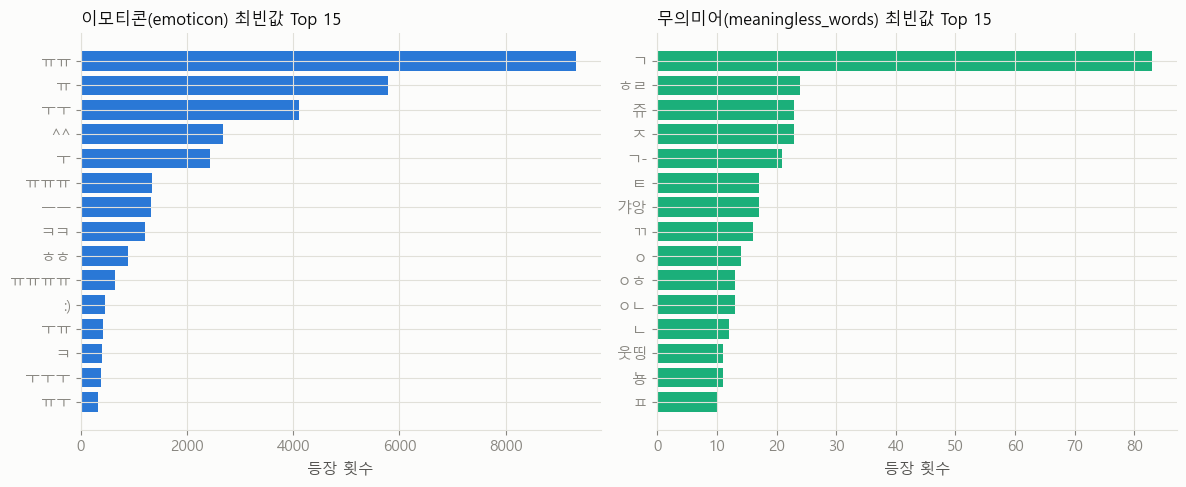

In [14]:
# 그래프는 읽기 쉽도록 15개만 보이고, 전체 값과 빈도는 CSV로 저장합니다.
emo_counts = pd.Series(emoticon_values, name="등장 횟수").sort_values(ascending=False)
mw_counts = pd.Series(meaningless_values, name="등장 횟수").sort_values(ascending=False)
full_counts_dir = os.path.join("output", "eda_quality")
os.makedirs(full_counts_dir, exist_ok=True)
emo_counts.rename_axis("value").to_csv(os.path.join(full_counts_dir, "emoticon_values_full.csv"), encoding="utf-8-sig")
mw_counts.rename_axis("value").to_csv(os.path.join(full_counts_dir, "meaningless_values_full.csv"), encoding="utf-8-sig")
print(f"이모티콘: 고유 표현 {len(emo_counts):,}개, 주석 총 {int(emo_counts.sum()):,}건")
print(f"무의미어: 고유 표현 {len(mw_counts):,}개, 주석 총 {int(mw_counts.sum()):,}건")
print(f"전체 빈도표 저장: {full_counts_dir}")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

emo_top = emo_counts.head(15).sort_values()
axes[0].barh(emo_top.index, emo_top.values, color=CAT[0])
axes[0].set_title("이모티콘(emoticon) 최빈값 Top 15", fontsize=12, color=INK, loc="left")
axes[0].set_xlabel("등장 횟수")

mw_top = mw_counts.head(15).sort_values()
axes[1].barh(mw_top.index, mw_top.values, color=CAT[2])
axes[1].set_title("무의미어(meaningless_words) 최빈값 Top 15", fontsize=12, color=INK, loc="left")
axes[1].set_xlabel("등장 횟수")

plt.tight_layout()
plt.show()


## 3. 교정 강도(유사도) 분석 - 전체 발화 기준

`form`과 `corrected_form` 사이의 `difflib.SequenceMatcher` 유사도를 **전체 발화**에 대해 계산해 "얼마나 많이 고쳐졌는지"를 정량화합니다. 그래프에서는 빈 발화를 제외하며, 1.0은 두 문자열이 동일하다는 뜻입니다. 이 값만으로 정답 문장이 옳다고 판정할 수는 없습니다.


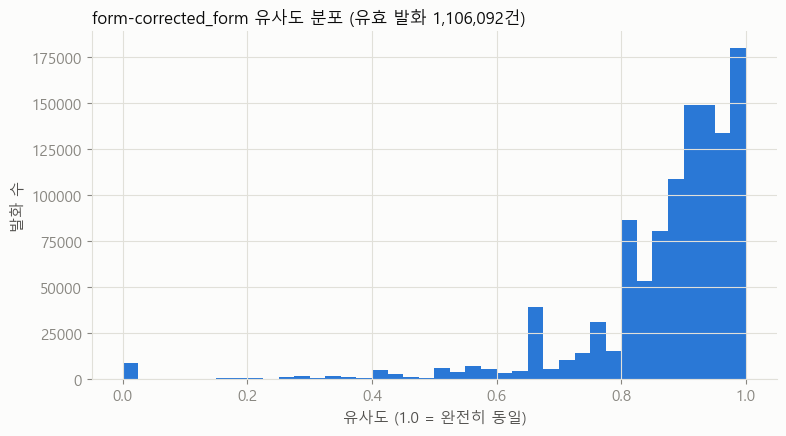

전체 발화: 1,129,363건 / 빈 발화 제외 유효 발화: 1,106,092건 / 제외된 빈 발화: 23,271건
유효 발화에서 유사도 정확히 1.0: 152,397건 (13.8%)
유효 발화 유사도 - 평균: 0.874, 중앙값: 0.909
※ 1.0은 form과 corrected_form이 같다는 뜻일 뿐, 둘 다 올바른 문장이라는 증거는 아닙니다.
※ 최종 평가는 변경 없음과 변경 있음에 대한 성능을 따로 보고하세요. 변경 없음도 과교정을 측정하므로 시험 데이터에서 전부 빼지 않습니다.


In [15]:
similarity_valid = df_similarity.loc[df_similarity["valid"]].copy()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(similarity_valid["similarity"], bins=40, color=CAT[0])
ax.set_title(f"form-corrected_form 유사도 분포 (유효 발화 {len(similarity_valid):,}건)", fontsize=12, color=INK, loc="left")
ax.set_xlabel("유사도 (1.0 = 완전히 동일)")
ax.set_ylabel("발화 수")
plt.tight_layout()
plt.show()

n_same = int(similarity_valid["similarity"].eq(1.0).sum())
print(f"전체 발화: {len(df_similarity):,}건 / 빈 발화 제외 유효 발화: {len(similarity_valid):,}건 / 제외된 빈 발화: {len(df_similarity)-len(similarity_valid):,}건")
print(f"유효 발화에서 유사도 정확히 1.0: {n_same:,}건 ({n_same / len(similarity_valid) * 100:.1f}%)")
print("유효 발화 유사도 - 평균: {:.3f}, 중앙값: {:.3f}".format(similarity_valid["similarity"].mean(), similarity_valid["similarity"].median()))
print("※ 1.0은 form과 corrected_form이 같다는 뜻일 뿐, 둘 다 올바른 문장이라는 증거는 아닙니다.")
print("※ 최종 평가는 변경 없음과 변경 있음에 대한 성능을 따로 보고하세요. 변경 없음도 과교정을 측정하므로 시험 데이터에서 전부 빼지 않습니다.")

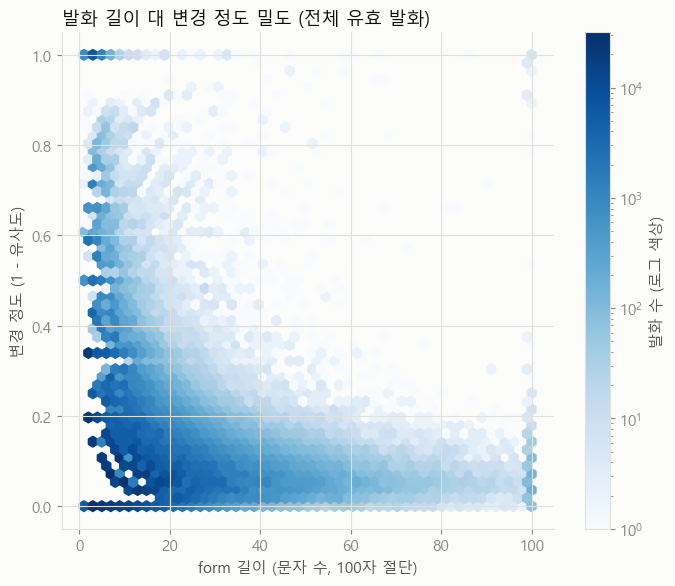

,발화 수,평균 변경 정도,중앙값 변경 정도
len_form,,,
1~5자,246866,0.212,0.167
6~15자,511904,0.116,0.091
16~30자,276869,0.081,0.069
31자 이상,70453,0.071,0.061


길이와 변경 정도의 순위 상관계수: -0.297 (0에 가까우면 뚜렷한 단조 관계가 약함)
※ 짧은 문장은 한 글자만 바뀌어도 변경 정도가 크게 보일 수 있습니다. 이 그림만으로 정답 품질이나 모델 성능을 판단하지 않습니다.


In [16]:
similarity_valid["change_amount"] = 1 - similarity_valid["similarity"]

fig, ax = plt.subplots(figsize=(7, 6))
density = ax.hexbin(similarity_valid["len_form"].clip(upper=100), similarity_valid["change_amount"], gridsize=50, mincnt=1, bins="log", cmap="Blues")
fig.colorbar(density, ax=ax, label="발화 수 (로그 색상)")
ax.set_title("발화 길이 대 변경 정도 밀도 (전체 유효 발화)", fontsize=13, color=INK, loc="left")
ax.set_xlabel("form 길이 (문자 수, 100자 절단)")
ax.set_ylabel("변경 정도 (1 - 유사도)")
plt.tight_layout()
plt.show()

# 육각형 칸 하나에 들어간 전체 발화 수를 색으로 표시합니다. 길이 구간별 건수와 평균도 함께 봅니다.
length_bucket = pd.cut(similarity_valid["len_form"], bins=[0, 5, 15, 30, float("inf")], labels=["1~5자", "6~15자", "16~30자", "31자 이상"])
length_change_table = similarity_valid.groupby(length_bucket, observed=False)["change_amount"].agg(["size", "mean", "median"])
length_change_table.columns = ["발화 수", "평균 변경 정도", "중앙값 변경 정도"]
display(length_change_table.round(3))
rank_corr = similarity_valid[["len_form", "change_amount"]].corr(method="spearman").iloc[0, 1]
print(f"길이와 변경 정도의 순위 상관계수: {rank_corr:.3f} (0에 가까우면 뚜렷한 단조 관계가 약함)")
print("※ 짧은 문장은 한 글자만 바뀌어도 변경 정도가 크게 보일 수 있습니다. 이 그림만으로 정답 품질이나 모델 성능을 판단하지 않습니다.")

[전체 주제별 전수 집계: 유효 발화와 문서 수]


,유효 발화 수,발화 기준 평균,문서 수,문서 균등 평균
topic,,,,
기타/일상,346523,0.155,191,0.149
식음료,153336,0.109,4471,0.108
쇼핑과 상품,65664,0.123,1840,0.123
콘텐츠>영상/음원 콘텐츠,61390,0.101,1727,0.099
가사 및 가족,50701,0.123,1391,0.123
...,...,...,...,...
"일상 트렌드>ESG(친환경, 사회, 지배구조) 활동",36,0.108,1,0.108
"시사(정치, 경제, 사회)>플랫폼 국감",35,0.090,1,0.090
"시사(정치, 경제, 사회)>미국 정보동맹 '파이브 아이즈' 한국 포함 추진",31,0.090,1,0.090


그림은 유효 발화 100건 이상인 주제 가운데 평균 상위 10개만 표시합니다.


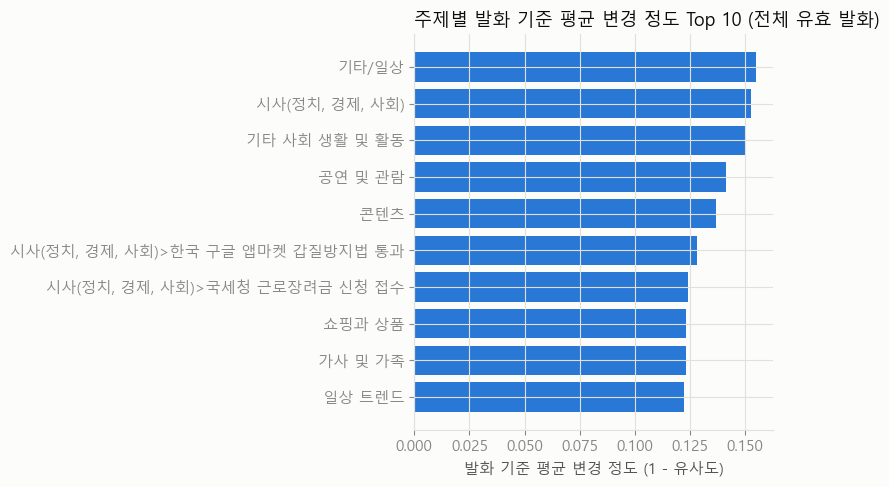

※ 그래프는 발화 하나씩의 평균입니다. 같은 대화가 길면 더 많이 반영되므로, 문서별 평균도 표에 함께 표시했습니다.


In [17]:
# 발화별 평균은 긴 대화의 발화가 더 큰 비중을 차지합니다. 문서별 평균도 별도로 제시합니다.
topic_stats = similarity_valid.groupby("topic")["change_amount"].agg(["size", "mean"])
topic_stats.columns = ["유효 발화 수", "발화 기준 평균"]
topic_stats["문서 수"] = similarity_valid.groupby("topic")["doc_id"].nunique()
per_doc = similarity_valid.groupby(["topic", "doc_id"])["change_amount"].mean()
topic_stats["문서 균등 평균"] = per_doc.groupby(level="topic").mean()
MIN_TOPIC_UTTS = 100
topic_top = topic_stats.loc[topic_stats["유효 발화 수"] >= MIN_TOPIC_UTTS].sort_values("발화 기준 평균", ascending=False).head(10)
print("[전체 주제별 전수 집계: 유효 발화와 문서 수]")
display(topic_stats.sort_values("유효 발화 수", ascending=False).round(3))
print(f"그림은 유효 발화 {MIN_TOPIC_UTTS}건 이상인 주제 가운데 평균 상위 10개만 표시합니다.")
topic_change = topic_top["발화 기준 평균"].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(topic_change.index, topic_change.values, color=CAT[0])
ax.set_title("주제별 발화 기준 평균 변경 정도 Top 10 (전체 유효 발화)", fontsize=13, color=INK, loc="left")
ax.set_xlabel("발화 기준 평균 변경 정도 (1 - 유사도)")
plt.tight_layout()
plt.show()

print("※ 그래프는 발화 하나씩의 평균입니다. 같은 대화가 길면 더 많이 반영되므로, 문서별 평균도 표에 함께 표시했습니다.")


## 4. 메타데이터 변수 중요도

성별·연령대·화자 관계 등의 분포가 크다고 해서 맞춤법 교정에 중요한 변수인 것은 아닙니다. 여기서는 **교정 필요 여부(`changed`: `form != corrected_form`)**를 목표값으로 두고 두 관점의 중요도를 함께 계산합니다.

1. **Cramér's V**: 다른 변수를 고려하지 않았을 때 각 변수와 교정 여부 사이의 연관성(0~1)
2. **순열 중요도**: 모든 변수를 함께 사용한 모델에서 한 변수를 무작위로 섞었을 때 검증 AUC가 얼마나 감소하는지 측정

순열 중요도는 문서 단위로 학습·검증 데이터를 분리해 같은 대화가 양쪽에 섞이지 않도록 합니다. `문장 길이`는 메타데이터의 중요도를 해석하기 위한 통제 변수이며, Cramér's V 계산에서는 길이를 10분위 구간으로 나눕니다.

> **해석 주의**: 이 결과는 변수와 교정 여부의 통계적 연관성 및 예측 기여도이지 인과관계가 아닙니다. 중요도가 높다고 해서 실제 맞춤법 교정 모델의 입력에 성별·연령 정보를 반드시 넣어야 한다는 뜻도 아닙니다. 텍스트만으로 같은 정보를 충분히 포착할 수 있는지 별도 실험이 필요합니다.


,feature,변수,Cramér's V,범주 간 교정률 차이(%p),범주 수
0,len_form,문장 길이,0.2758,33.3889,10
1,relation,화자 관계,0.0943,19.2079,29
2,publisher,플랫폼,0.0924,6.6694,2
3,topic,대화 주제,0.0842,9.9074,66
4,age,연령대,0.0691,5.2017,4
5,sex,성별,0.0396,4.2779,2


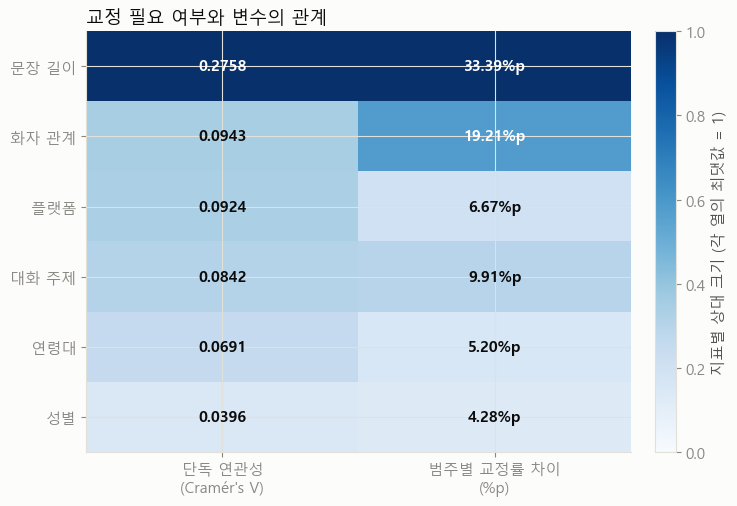

읽는 법: 진한 칸일수록 같은 열 안에서 상대적으로 큰 값입니다. 두 열의 색을 서로 직접 비교하면 안 됩니다.


In [18]:
# 변수별 단독 연관성: Cramér's V와 범주 간 교정률 차이
IMPORTANCE_FEATURES = ["publisher", "topic", "relation", "sex", "age", "len_form"]
FEATURE_LABELS = {
    "publisher": "플랫폼",
    "topic": "대화 주제",
    "relation": "화자 관계",
    "sex": "성별",
    "age": "연령대",
    "len_form": "문장 길이",
}

def cramers_v(feature, target):
    table = pd.crosstab(feature, target).to_numpy(dtype=float)
    n = table.sum()
    if n <= 1 or min(table.shape) <= 1:
        return 0.0
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / n
    valid = expected > 0
    chi2 = (((table - expected) ** 2 / np.where(valid, expected, 1))[valid]).sum()
    phi2 = chi2 / n
    r, k = table.shape
    # 표본 크기가 클 때 범주 수가 많은 변수에 생기는 편향을 보정
    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return float(np.sqrt(phi2_corr / denom)) if denom > 0 else 0.0

importance_base = df[["changed"] + IMPORTANCE_FEATURES].copy()
for col in ["publisher", "topic", "relation", "sex", "age"]:
    importance_base[col] = importance_base[col].fillna("<결측>").astype(str)

# 길이는 연속형이므로 분위수 구간으로 바꿔 범주형 효과크기와 비교합니다.
importance_base["len_form_group"] = pd.qcut(
    importance_base["len_form"], q=10, duplicates="drop"
).astype(str)

association_rows = []
for feature in IMPORTANCE_FEATURES:
    effect_feature = importance_base["len_form_group"] if feature == "len_form" else importance_base[feature]
    category_stats = (
        pd.DataFrame({"feature": effect_feature, "changed": importance_base["changed"]})
        .groupby("feature", observed=True)["changed"]
        .agg(["mean", "count"])
    )
    # 극소 범주의 우연한 0%/100%가 범위 값을 왜곡하지 않도록 최소 500발화 이상만 사용
    stable_rates = category_stats.loc[category_stats["count"] >= 500, "mean"]
    rate_range = float((stable_rates.max() - stable_rates.min()) * 100) if len(stable_rates) else np.nan
    association_rows.append({
        "feature": feature,
        "변수": FEATURE_LABELS[feature],
        "Cramér's V": cramers_v(effect_feature, importance_base["changed"]),
        "범주 간 교정률 차이(%p)": rate_range,
        "범주 수": int(effect_feature.nunique(dropna=False)),
    })

association_df = pd.DataFrame(association_rows)
association_view = association_df.sort_values("Cramér's V", ascending=False).reset_index(drop=True)
display(association_view.round(4))

# 지표마다 단위가 다르므로 색은 각 열의 최댓값을 1로 맞추고, 칸 안에는 실제 값을 표시합니다.
heatmap_values = association_view.set_index("변수")[["Cramér's V", "범주 간 교정률 차이(%p)"]]
heatmap_colors = heatmap_values.div(heatmap_values.max().replace(0, 1), axis=1)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
image = ax.imshow(heatmap_colors.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(2))
ax.set_xticklabels(["단독 연관성\n(Cramér's V)", "범주별 교정률 차이\n(%p)"])
ax.set_yticks(range(len(heatmap_values)))
ax.set_yticklabels(heatmap_values.index)

for row in range(len(heatmap_values)):
    for col in range(2):
        value = heatmap_values.iloc[row, col]
        label = f"{value:.4f}" if col == 0 else f"{value:.2f}%p"
        text_color = "white" if heatmap_colors.iloc[row, col] >= 0.55 else INK
        ax.text(col, row, label, ha="center", va="center", color=text_color, fontweight="bold")

ax.set_title("교정 필요 여부와 변수의 관계", fontsize=13, color=INK, loc="left")
cbar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.04)
cbar.set_label("지표별 상대 크기 (각 열의 최댓값 = 1)")
plt.tight_layout()
plt.show()

print("읽는 법: 진한 칸일수록 같은 열 안에서 상대적으로 큰 값입니다. 두 열의 색을 서로 직접 비교하면 안 됩니다.")


### 4-1. 위 결과가 신뢰할 만한지 점검

Cramér's V 계산 자체가 잡음을 진짜 연관성으로 잘못 읽는 건 아닌지, 그리고 임의로 정한 길이 10분위 처리에 결과가 민감한 건 아닌지 확인합니다. 모든 발화의 값으로 계산합니다.


In [19]:
# 검증 1) 타깃을 무작위로 섞으면 Cramér's V가 0 근처로 떨어져야 정상입니다.
# (그렇지 않다면 계산 자체에 편향이나 버그가 있다는 신호)
rng_check = np.random.default_rng(0)
shuffled_changed = pd.Series(rng_check.permutation(importance_base["changed"].to_numpy()))

sanity_rows = []
for feature in IMPORTANCE_FEATURES:
    effect_feature = importance_base["len_form_group"] if feature == "len_form" else importance_base[feature]
    sanity_rows.append({
        "변수": FEATURE_LABELS[feature],
        "실제 타깃 Cramér's V": cramers_v(effect_feature, importance_base["changed"]),
        "무작위 타깃 Cramér's V (기대값 ~0)": cramers_v(effect_feature, shuffled_changed),
    })

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df.round(4))


,변수,실제 타깃 Cramér's V,무작위 타깃 Cramér's V (기대값 ~0)
0,플랫폼,0.0924,0.0013
1,대화 주제,0.0842,0.0000
2,화자 관계,0.0943,0.0000
3,성별,0.0396,0.0002
4,연령대,0.0691,0.0000
5,문장 길이,0.2758,0.0022


In [20]:
# 검증 2) len_form을 10분위가 아니라 다른 구간 수로 나눠도 결론이 유지되는지 확인
bin_sensitivity_rows = []
for q in [5, 10, 20, 30]:
    len_group = pd.qcut(importance_base["len_form"], q=q, duplicates="drop").astype(str)
    v = cramers_v(len_group, importance_base["changed"])
    bin_sensitivity_rows.append({"분위 수(q)": q, "실제 구간 수": len_group.nunique(), "Cramér's V": v})

bin_sensitivity_df = pd.DataFrame(bin_sensitivity_rows)
display(bin_sensitivity_df.round(4))


,분위 수(q),실제 구간 수,Cramér's V
0,5,5,0.2500
1,10,10,0.2758
2,20,20,0.2823
3,30,25,0.3012


In [21]:
# 위 두 검증은 전체 발화를 사용합니다. 아래 예측 모델도 25만 건 제한을 두지 않습니다.
print(f"메타데이터 분석 전체 발화: {len(importance_base):,}건 (원본 파싱 {len(df):,}건)")
assert len(importance_base) == len(df)


메타데이터 분석 전체 발화: 1,129,363건 (원본 파싱 1,129,363건)


> **실행 환경 참고**: 아래 순열 중요도 셀에는 scikit-learn이 필요합니다. 전체 발화를 내부 학습·검증에 나눠 사용하므로 실행 시간이 길 수 있습니다. 저장된 출력이 현재 코드의 실행 결과인지 확인하고, 결과를 다시 생성하려면 이 셀을 실행하세요.

> **참고**: `class_weight="balanced"`가 ROC-AUC의 변수 간 순위 자체에 영향을 주는지는 이 노트북에서 검증되지 않았습니다. 로컬 환경에서 이 옵션을 켰을 때/껐을 때 AUC 순위가 같은지 한 번 비교해보는 것을 권장합니다.


예측 기반 중요도에 쓰는 전체 발화: 1,129,363건
문서 단위 검증 ROC-AUC: 0.7133


,변수,Cramér's V,범주 간 교정률 차이(%p),AUC 감소량,상대 중요도(0~100),중요도 등급
0,문장 길이,0.2758,33.39,0.19194,100.0,매우 높음
1,연령대,0.0691,5.20,0.01418,7.4,낮음
2,대화 주제,0.0842,9.91,0.00237,1.2,낮음
3,플랫폼,0.0924,6.67,0.00098,0.5,낮음
4,화자 관계,0.0943,19.21,0.00093,0.5,낮음
5,성별,0.0396,4.28,-0.00019,0.0,확인되지 않음


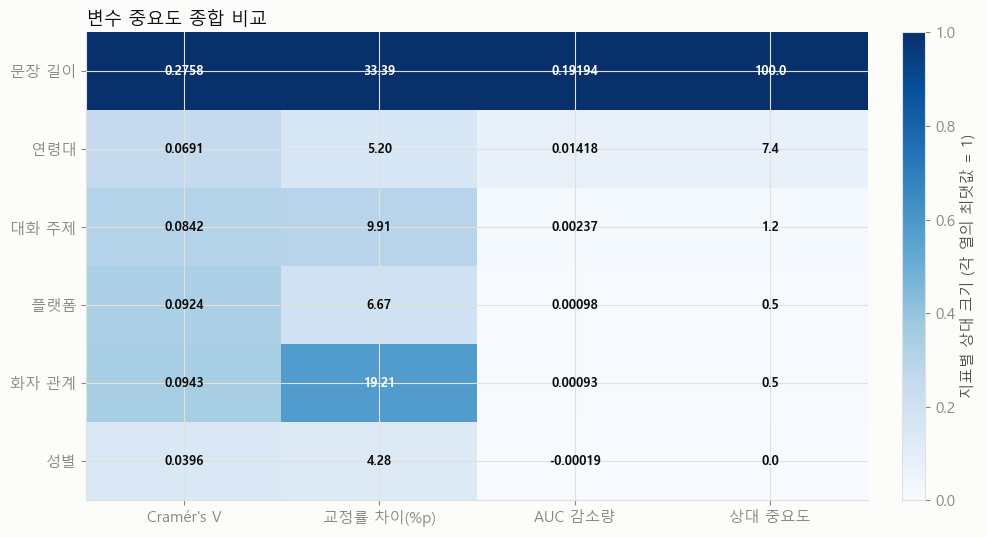

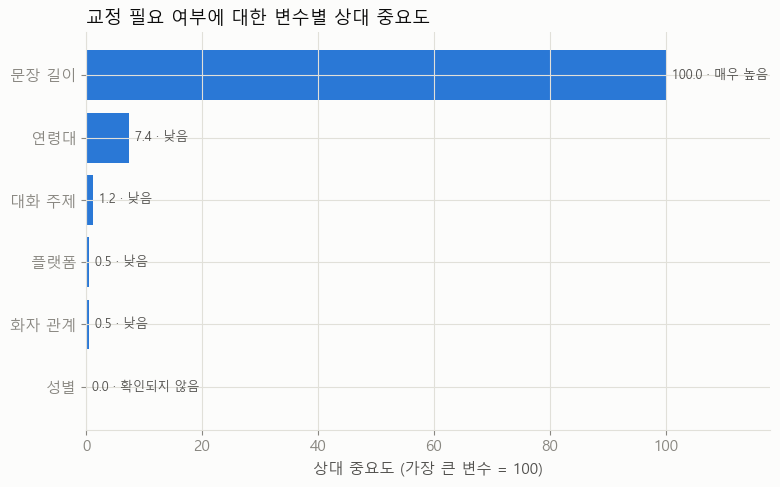

해석 기준:
- Cramér's V가 크면 해당 변수 하나만 보아도 교정 여부 차이가 큽니다.
- AUC 감소량과 상대 중요도가 크면 다른 변수를 고려한 뒤에도 고유한 예측 정보가 남습니다.
- 중요도가 낮은 인구통계 변수는 교정 모델 입력에서 제외하고 텍스트만 사용하는 편이 단순하고 안전합니다.


In [22]:
# 여러 변수를 동시에 고려한 예측 기반 순열 중요도
# requirements.txt의 scikit-learn이 필요합니다.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CAT_FEATURES = ["publisher", "topic", "relation", "sex", "age"]
NUM_FEATURES = ["len_form"]
MODEL_FEATURES = CAT_FEATURES + NUM_FEATURES

# 전체 발화를 사용합니다. 모델의 성능 확인을 위해 문서 단위 학습·검증 분할은 유지합니다.
model_df = df[["doc_id", "changed"] + MODEL_FEATURES].copy()
print(f"예측 기반 중요도에 쓰는 전체 발화: {len(model_df):,}건")

for col in CAT_FEATURES:
    model_df[col] = model_df[col].fillna("<결측>").astype(str)

# 동일 문서의 발화가 학습·검증 양쪽에 섞이지 않도록 문서 그룹 단위로 분할
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, valid_idx = next(splitter.split(model_df, groups=model_df["doc_id"]))
train_part = model_df.iloc[train_idx]
valid_part = model_df.iloc[valid_idx]

preprocess = ColumnTransformer([
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
    ]), CAT_FEATURES),
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler(with_mean=False)),
    ]), NUM_FEATURES),
])

# 대규모 희소 원-핫 데이터에 빠른 로지스틱 손실 선형 분류기
importance_model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", SGDClassifier(
        loss="log_loss", alpha=1e-5, max_iter=1000, tol=1e-3,
        class_weight="balanced", random_state=42,
    )),
])

X_train, y_train = train_part[MODEL_FEATURES], train_part["changed"].astype(int)
X_valid, y_valid = valid_part[MODEL_FEATURES], valid_part["changed"].astype(int)
importance_model.fit(X_train, y_train)

base_probability = importance_model.predict_proba(X_valid)[:, 1]
base_auc = roc_auc_score(y_valid, base_probability)
print(f"문서 단위 검증 ROC-AUC: {base_auc:.4f}")

# 한 변수씩 섞은 뒤 AUC 감소량을 계산합니다. 값이 클수록 해당 변수의 고유 기여도가 큽니다.
rng = np.random.default_rng(42)
permutation_rows = []
N_REPEATS = 5
for feature in MODEL_FEATURES:
    shuffled_aucs = []
    for _ in range(N_REPEATS):
        shuffled = X_valid.copy()
        shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())
        probability = importance_model.predict_proba(shuffled)[:, 1]
        shuffled_aucs.append(roc_auc_score(y_valid, probability))
    auc_drop = base_auc - float(np.mean(shuffled_aucs))
    permutation_rows.append({
        "feature": feature,
        "AUC 감소량": auc_drop,
        "반복 표준편차": float(np.std(shuffled_aucs)),
    })

permutation_df = pd.DataFrame(permutation_rows)
importance_df = association_df.merge(permutation_df, on="feature", how="left")

# 0 미만은 잡음 범위로 보고 0으로 처리한 뒤, 가장 큰 변수를 100으로 둔 상대점수로 변환합니다.
positive_drop = importance_df["AUC 감소량"].clip(lower=0)
max_drop = positive_drop.max()
importance_df["상대 중요도(0~100)"] = 0.0 if max_drop <= 0 else positive_drop / max_drop * 100

# 참고: 아래 75/40/15 경계값은 임의로 정한 것으로, 다른 경계값을 쓰면 등급이 바뀔 수 있습니다.
# 절대적 기준이 아니라 상대 순위를 읽기 쉽게 하기 위한 보조 표시일 뿐입니다.
def importance_level(score):
    if score >= 75:
        return "매우 높음"
    if score >= 40:
        return "높음"
    if score >= 15:
        return "보통"
    if score > 0:
        return "낮음"
    return "확인되지 않음"

importance_df["중요도 등급"] = importance_df["상대 중요도(0~100)"].map(importance_level)
importance_df = importance_df.sort_values("상대 중요도(0~100)", ascending=False).reset_index(drop=True)

display_columns = [
    "변수", "Cramér's V", "범주 간 교정률 차이(%p)",
    "AUC 감소량", "상대 중요도(0~100)", "중요도 등급",
]
display(importance_df[display_columns].round({
    "Cramér's V": 4,
    "범주 간 교정률 차이(%p)": 2,
    "AUC 감소량": 5,
    "상대 중요도(0~100)": 1,
}))

# 단독 연관성과 다변수 예측 기여도를 한눈에 비교하는 종합 히트맵
combined_values = importance_df.set_index("변수")[[
    "Cramér's V", "범주 간 교정률 차이(%p)", "AUC 감소량", "상대 중요도(0~100)"
]]
combined_colors = combined_values.clip(lower=0).div(
    combined_values.clip(lower=0).max().replace(0, 1), axis=1
)

fig, ax = plt.subplots(figsize=(10, 5.5))
image = ax.imshow(combined_colors.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["Cramér's V", "교정률 차이(%p)", "AUC 감소량", "상대 중요도"])
ax.set_yticks(range(len(combined_values)))
ax.set_yticklabels(combined_values.index)
formats = [".4f", ".2f", ".5f", ".1f"]
for row in range(len(combined_values)):
    for col, number_format in enumerate(formats):
        value = combined_values.iloc[row, col]
        text_color = "white" if combined_colors.iloc[row, col] >= 0.55 else INK
        ax.text(col, row, format(value, number_format), ha="center", va="center",
                color=text_color, fontsize=9, fontweight="bold")
ax.set_title("변수 중요도 종합 비교", fontsize=13, color=INK, loc="left")
cbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("지표별 상대 크기 (각 열의 최댓값 = 1)")
plt.tight_layout()
plt.show()

plot_df = importance_df.sort_values("상대 중요도(0~100)")
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(plot_df["변수"], plot_df["상대 중요도(0~100)"], color=CAT[0])
for bar, value, level in zip(bars, plot_df["상대 중요도(0~100)"], plot_df["중요도 등급"]):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2, f"{value:.1f} · {level}",
            va="center", fontsize=9, color=INK_SECOND)
ax.set_xlim(0, max(105, plot_df["상대 중요도(0~100)"].max() + 18))
ax.set_xlabel("상대 중요도 (가장 큰 변수 = 100)")
ax.set_title("교정 필요 여부에 대한 변수별 상대 중요도", fontsize=13, color=INK, loc="left")
plt.tight_layout()
plt.show()

print("해석 기준:")
print("- Cramér's V가 크면 해당 변수 하나만 보아도 교정 여부 차이가 큽니다.")
print("- AUC 감소량과 상대 중요도가 크면 다른 변수를 고려한 뒤에도 고유한 예측 정보가 남습니다.")
print("- 중요도가 낮은 인구통계 변수는 교정 모델 입력에서 제외하고 텍스트만 사용하는 편이 단순하고 안전합니다.")


## 5. corrected_form 품질 점검

`corrected_form`을 정답으로 그대로 믿을 수 있는지 **모델을 학습하기 전에** 확인하는 구간입니다. 이 구간의 규칙은 모두 "의심 사례를 자동으로 찾는 필터"이지 오류 판정기가 아닙니다.

**읽을 때 지켜야 할 원칙**
- 플래그가 붙은 건수는 오류 건수가 아닙니다. 아래 5.5의 표본 정밀도 확인을 거치기 전에는 "의심 후보"로만 부릅니다.
- 플래그가 붙지 않았다고 깨끗한 데이터라는 뜻도 아닙니다. 특히 **교정 누락은 정답이 없어 규칙으로 측정할 수 없습니다.**
- 임계값(길이 비율, 편집량, 문장부호 증가량 등)은 **초기값**입니다. 분포와 민감도 표를 본 뒤 조정하고, 조정 근거를 남겨야 합니다.
- 이 구간은 데이터 품질만 다룹니다. 모델 성능이나 최종 정답 품질에 대한 결론은 내리지 않습니다.
- 원본 JSON은 읽기 전용으로만 열며, 시작과 끝의 SHA-256을 비교해 확인합니다. `corrected_form`을 다른 값으로 덮어쓰지 않습니다. 결과는 별도 폴더(`output/eda_quality/`)의 CSV로만 저장합니다.

In [23]:
# 5.0 form / corrected_form 텍스트 재파싱 (원본 JSON은 읽기 전용으로만 엽니다)
import json, hashlib, time, difflib
from collections import Counter
from IPython.display import display

SEED = 42

def sha256_of(path, chunk=1 << 24):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

SRC_HASH_BEFORE = sha256_of(DATA_PATH)
print("원본 SHA-256(시작):", SRC_HASH_BEFORE)

def _unescape(raw):
    """JSON 문자열 이스케이프(\\\", \\uXXXX 등)를 실제 문자로 복원합니다."""
    if "\\" not in raw:
        return raw
    try:
        return json.loads('"' + raw + '"')
    except Exception:
        return raw

def parse_texts(path):
    id_re = re.compile(r'"id":\s*"([^"]+)"')
    val_re = {k: re.compile(r'"%s":\s*"(.*)",?$' % k) for k in ("original_form", "form", "corrected_form")}
    rows = []
    doc = utt = None
    orig = form = corr = ""
    t0 = time.time()
    with open(path, "r", encoding="utf-8") as f:          # 읽기 전용
        for line in f:
            s = line.strip()
            if s.startswith('"id":'):
                m = id_re.search(s)
                if m:
                    v = m.group(1)
                    n_dot = v.count(".")
                    if n_dot == 1:
                        doc = v                            # 문서 ID 예: MDRW2100000002.1
                    elif n_dot >= 2:
                        utt = v                            # 발화 ID 예: MDRW2100000002.1.1
            elif s.startswith('"original_form":'):
                m = val_re["original_form"].search(s); orig = _unescape(m.group(1)) if m else ""
            elif s.startswith('"form":'):
                m = val_re["form"].search(s); form = _unescape(m.group(1)) if m else ""
            elif s.startswith('"corrected_form":'):
                m = val_re["corrected_form"].search(s); corr = _unescape(m.group(1)) if m else ""
            elif s.startswith('"speaker_id":'):
                rows.append((doc, utt, orig, form, corr))
                orig = form = corr = ""
    print(f"텍스트 파싱 완료: {time.time()-t0:.0f}s 소요")
    return pd.DataFrame(rows, columns=["doc_id", "utt_id", "original_form", "form", "corrected"])

q = parse_texts(DATA_PATH)
print(f"발화 수: {len(q):,} (앞 파싱 결과 df: {len(df):,}) -> 일치 여부: {len(q) == len(df)}")
print(f"발화 ID 중복: {q['utt_id'].duplicated().sum():,}건 / 문서 수: {q['doc_id'].nunique():,}")

원본 SHA-256(시작): 592e81cf9c41f6ee7e30dc660cb8d3f1c282275deca7eca25d64ab1a9acdec39
텍스트 파싱 완료: 5s 소요
발화 수: 1,129,363 (앞 파싱 결과 df: 1,129,363) -> 일치 여부: True
발화 ID 중복: 0건 / 문서 수: 21,335


### 5.1 변경 유형 분류와 길이 분포

발화마다 아래 순서로 검사해 **하나의 유형에만** 배정합니다(앞 조건에 걸리면 뒤 조건은 보지 않음).

1. 변경 없음: `form == corrected_form`
2. 띄어쓰기만 변경: 공백을 모두 지우면 같음
3. 문장부호 중심 변경: 공백과 문장부호를 모두 지우면 같음
4. 철자·단어 수준 변경: 위에 해당하지 않음

`form`이나 `corrected_form`이 비어 있는 발화(공유·이모지 메시지 등)는 "변경 없음"에 섞이면 안 되므로 별도 행으로 분리하고, 이후 비율의 분모에서도 뺍니다(`유효 발화` = 둘 다 비어 있지 않은 발화). 유형 4는 글자 단위 편집량(1 - difflib 유사도)으로 소폭·중간·대폭을 나눕니다. 이 구간 경계(0.2, 0.5)는 임의의 초기값이므로 분포 그림으로 타당성을 먼저 확인하세요.

기존 df.edit_type 과 분류가 다른 발화: 0건 (이 중 form/corrected_form 에 줄바꿈·탭이 있는 발화 0건)
  → 차이가 있다면 두 분류 기준을 다시 확인하세요.
편집량 계산 267,662건, 6s


,유형,건수,비율(%),분모
0,(제외) form 또는 corrected_form이 빈 값,23271,2.06,전체 발화 대비
1,변경 없음,152397,13.78,유효 발화 대비
2,띄어쓰기만 변경,98346,8.89,유효 발화 대비
3,문장부호 중심 변경,587687,53.13,유효 발화 대비
4,철자·단어 수준 변경,267662,24.20,유효 발화 대비
5,└ 소폭 (편집량 < 0.2),152738,13.81,유효 발화 대비
6,└ 중간 (0.2 ~ 0.5),88660,8.02,유효 발화 대비
7,└ 대폭 (≥ 0.5),26264,2.37,유효 발화 대비



[유효 발화의 공백 제외 글자 수 분위수]


,1%,5%,25%,50%,75%,95%,99%,최대
form,1.0,2.0,5.0,9.0,15.0,27.0,42.0,5135.0
corrected_form,2.0,3.0,6.0,10.0,15.0,28.0,43.0,5157.0


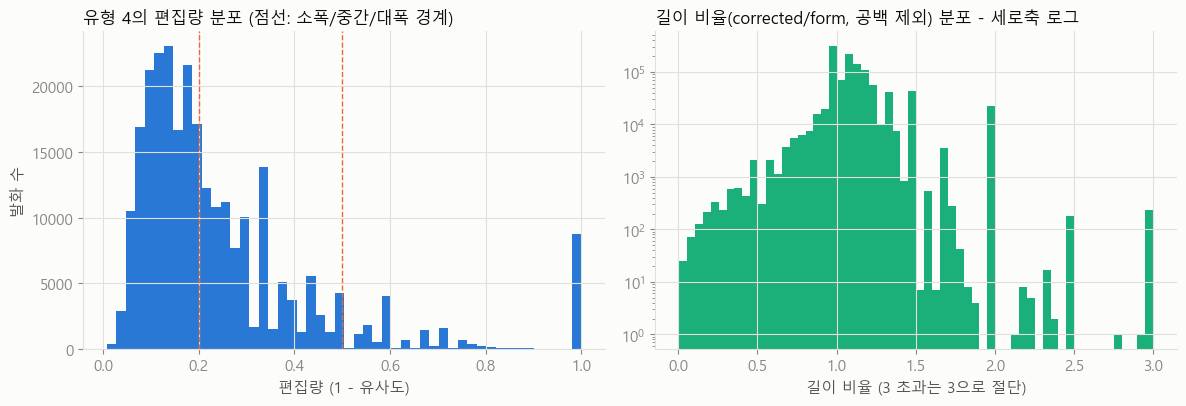

In [24]:
# 5.1 기본 파생 변수와 변경 유형
PUNCT_RE = "[" + re.escape("".join(sorted(PUNCT_CHARS))) + "]"        # 앞 셀의 PUNCT_CHARS 재사용
PUNCT_TABLE = str.maketrans("", "", "".join(PUNCT_CHARS))

q["form_blank"] = q["form"].str.strip().eq("")
q["corr_blank"] = q["corrected"].str.strip().eq("")
q["valid"] = ~q["form_blank"] & ~q["corr_blank"]                          # 둘 다 내용이 있는 발화
N_ALL, N_VALID = len(q), int(q["valid"].sum())

q["ns_f"] = q["form"].str.replace(r"\s+", "", regex=True)
q["ns_c"] = q["corrected"].str.replace(r"\s+", "", regex=True)
q["len_f"] = q["ns_f"].str.len()                                          # 공백 제외 글자 수
q["len_c"] = q["ns_c"].str.len()
q["len_f_np"] = q["ns_f"].str.translate(PUNCT_TABLE).str.len()               # 공백·문장부호 제외 글자 수 (길이 규칙에서 사용)
q["len_c_np"] = q["ns_c"].str.translate(PUNCT_TABLE).str.len()

same = q["form"].eq(q["corrected"])
same_nospace = q["ns_f"].eq(q["ns_c"])
same_nopunct = q["ns_f"].str.translate(PUNCT_TABLE).eq(q["ns_c"].str.translate(PUNCT_TABLE))
q["edit_type"] = np.select([same, same_nospace, same_nopunct], [0, 1, 2], default=3)
q["changed"] = q["edit_type"].ne(0)

# 앞 셀(df)의 edit_type과 같은 기준으로 계산했는지 교차 확인
if len(df) == len(q):
    ok = q["valid"].to_numpy()
    mism = ok & (q["edit_type"].to_numpy() != df["edit_type"].to_numpy())
    has_ctrl = (q["form"].str.contains(r"[\r\n\t]") | q["corrected"].str.contains(r"[\r\n\t]")).to_numpy()
    print(f"기존 df.edit_type 과 분류가 다른 발화: {int(mism.sum()):,}건 (이 중 form/corrected_form 에 줄바꿈·탭이 있는 발화 {int((mism & has_ctrl).sum()):,}건)")
    print("  → 차이가 있다면 두 분류 기준을 다시 확인하세요.")

# 유형 3(철자·단어 수준)은 편집량으로 세분화 (전수 계산: difflib 사용, 수 분 이내)
t0 = time.time()
q["edit_ratio"] = np.nan
idx3 = np.flatnonzero((q["edit_type"] == 3).to_numpy() & q["valid"].to_numpy())
fv, cv = q["form"].to_numpy(), q["corrected"].to_numpy()
er = np.empty(len(idx3))
for k, i in enumerate(idx3):
    er[k] = 1.0 - difflib.SequenceMatcher(None, fv[i], cv[i], autojunk=False).ratio()
q.loc[q.index[idx3], "edit_ratio"] = er
print(f"편집량 계산 {len(idx3):,}건, {time.time()-t0:.0f}s")

TYPE_LABEL = {0: "변경 없음", 1: "띄어쓰기만 변경", 2: "문장부호 중심 변경", 3: "철자·단어 수준 변경"}
rows = [["(제외) form 또는 corrected_form이 빈 값", N_ALL - N_VALID, (N_ALL - N_VALID) / N_ALL * 100, "전체 발화 대비"]]
vt = q.loc[q["valid"], "edit_type"].value_counts().reindex(range(4)).fillna(0).astype(int)
for k in range(4):
    rows.append([TYPE_LABEL[k], int(vt[k]), vt[k] / N_VALID * 100, "유효 발화 대비"])
sub = q.loc[q["valid"] & (q["edit_type"] == 3), "edit_ratio"]
for lab, lo, hi in [("  └ 소폭 (편집량 < 0.2)", 0, 0.2), ("  └ 중간 (0.2 ~ 0.5)", 0.2, 0.5), ("  └ 대폭 (≥ 0.5)", 0.5, 9)]:
    c = int(((sub >= lo) & (sub < hi)).sum())
    rows.append([lab, c, c / N_VALID * 100, "유효 발화 대비"])
type_table = pd.DataFrame(rows, columns=["유형", "건수", "비율(%)", "분모"])
type_table["비율(%)"] = type_table["비율(%)"].round(2)
display(type_table)

# 유효 발화 기준 길이 분포(공백 제외 글자 수): 평균 대신 분위수를 봅니다
qs = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]
len_tab = pd.DataFrame({"form": q.loc[q["valid"], "len_f"].quantile(qs), "corrected_form": q.loc[q["valid"], "len_c"].quantile(qs)}).T
len_tab.columns = ["1%", "5%", "25%", "50%", "75%", "95%", "99%", "최대"]
print("\n[유효 발화의 공백 제외 글자 수 분위수]")
display(len_tab)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(sub.clip(upper=1), bins=50, color=CAT[0])
for x in (0.2, 0.5):
    axes[0].axvline(x, color=CAT[1], ls="--", lw=1)
axes[0].set_title("유형 4의 편집량 분포 (점선: 소폭/중간/대폭 경계)", loc="left", fontsize=12, color=INK)
axes[0].set_xlabel("편집량 (1 - 유사도)"); axes[0].set_ylabel("발화 수")
vq = q[q["valid"] & (q["len_f"] > 0)]
axes[1].hist((vq["len_c"] / vq["len_f"]).clip(upper=3), bins=60, color=CAT[2])
axes[1].set_yscale("log")
axes[1].set_title("길이 비율(corrected/form, 공백 제외) 분포 - 세로축 로그", loc="left", fontsize=12, color=INK)
axes[1].set_xlabel("길이 비율 (3 초과는 3으로 절단)")
plt.tight_layout(); plt.show()
q.drop(columns=["ns_f", "ns_c"], inplace=True)      # 메모리 절약 (이후 셀에서는 len_f / len_c 만 사용)

### 5.2 의심 사례 탐지 규칙

플래그는 **다중 라벨**입니다(한 발화가 여러 규칙에 걸릴 수 있음). 각 규칙이 무엇을 잡고, 어떤 정상 사례를 잘못 잡을 수 있는지를 함께 적어 둡니다.

| 규칙(열 이름) | 정의 | 정상인데 걸릴 수 있는 경우 |
|---|---|---|
| `flag_empty_corr` / `flag_empty_form` | 한쪽만 비어 있음 | 거의 없음 (둘 다 빈 발화는 5.1에서 분리) |
| `flag_len_long` / `flag_len_short` | 공백·문장부호를 뺀 글자 수의 비율(corrected/form)이 기준 밖이고 절대 차이도 `LEN_ABS_MIN`자 이상 | 문장부호 추가·삭제(`!!!!!`→`!`)는 길이 변화로 세지 않음. 짧은 문장은 1~2자 차이로도 비율이 크게 변하므로 절대 차이 조건을 함께 사용 |
| `flag_edit_large` | 철자·단어 수준 변경 중 편집량이 `EDIT_RATIO_HI` 이상 | 짧은 발화의 정당한 어절 교체 |
| `flag_deid` | 비식별화 토큰(`name2`, `address` 등)의 개수·종류가 달라짐(대소문자만 바뀐 경우는 따로 집계) | 낮음. 정보 손실 가능성이 있는 우선 확인 대상 |
| `flag_digit` / `flag_alpha` | 숫자열 / 영문열의 다중집합이 달라짐(비식별화 토큰은 제외 후 비교) | 숫자의 한글 표기 변환("3개"→"세 개"), 대소문자만 변경(별도 표시) |
| `flag_emoji` / `flag_textemo` / `flag_jamo` | 이모지 / 문자 이모티콘(`^^`, `-_-`) / 자모 단독열(`ㅋㅋ`, `ㅠㅠ`)이 달라짐 | 자모열은 오타 교정 과정에서 정당하게 바뀌는 경우가 많음. `사라짐`, `추가됨`, `반복 길이만 변경`으로 세분화해서 봄 |
| `flag_conflict` / `flag_conflict_long` | 같은 `form`에 서로 다른 `corrected_form`이 2종 이상 붙음(`_long`은 `CONFLICT_MIN_LEN`자 이상) | 문맥이 다른 동형어, 아주 짧은 발화("네", "ㅇㅇ") |
| `flag_punct_excess` | 문장부호 증가량이 `PUNCT_ADD_MIN` 이상이거나 같은 부호가 4개 이상 연속(`!!!!`, `....`)으로 새로 생김(`...`은 정상 표기로 보고 제외) | 문장 끝 마침표 추가가 데이터 전반의 일관된 정책일 수 있음(아래 표로 확인) |

**측정하지 않는 것**: 교정 누락(고쳐야 하는데 안 고친 경우)과 잘못된 교정 중 위 규칙에 걸리지 않는 것은 이 규칙들로 알 수 없습니다.

In [25]:
# 5.2-a 빈값 / 길이 / 편집량 / 문장부호 규칙 (임계값은 초기값이며 아래 민감도 표로 점검)
LEN_RATIO_LO, LEN_RATIO_HI, LEN_ABS_MIN = 0.7, 1.5, 3
EDIT_RATIO_HI = 0.5
PUNCT_ADD_MIN = 3
CONFLICT_MIN_LEN = 5

v = q["valid"]
q["flag_empty_corr"] = q["corr_blank"] & ~q["form_blank"]
q["flag_empty_form"] = q["form_blank"] & ~q["corr_blank"]

ratio = (q["len_c_np"] / q["len_f_np"].where(q["len_f_np"] > 0)).where(v)          # 공백·문장부호 제외 길이 비율
diff_len = (q["len_c_np"] - q["len_f_np"]).where(v)
q["len_ratio"] = ratio
q["flag_len_long"] = (ratio > LEN_RATIO_HI) & (diff_len >= LEN_ABS_MIN)
q["flag_len_short"] = (ratio < LEN_RATIO_LO) & (-diff_len >= LEN_ABS_MIN)
q["flag_edit_large"] = q["edit_ratio"].ge(EDIT_RATIO_HI)

# 문장부호 증가량
q["p_f"] = q["form"].str.count(PUNCT_RE)
q["p_c"] = q["corrected"].str.count(PUNCT_RE)
q["p_add"] = (q["p_c"] - q["p_f"]).where(v)
REPEAT_RE = re.compile(r"([.!?~…])\1{3,}")                 # 같은 부호 4개 이상 연속 ('...' 는 정상 표기로 보고 제외)
new_repeat = q["corrected"].str.contains(REPEAT_RE) & ~q["form"].str.contains(REPEAT_RE)
q["flag_punct_excess"] = v & ((q["p_add"] >= PUNCT_ADD_MIN) | new_repeat)

# ---- 분포와 민감도: 임계값이 결과를 얼마나 좌우하는지 ----
print("[길이 비율(corrected/form, 공백·문장부호 제외) 분위수 - 유효 발화]")
display(ratio.quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).round(3).to_frame("길이 비율").T)

grid = []
for lo, hi in [(0.8, 1.25), (0.7, 1.5), (0.5, 2.0)]:
    for a in (2, 3, 5):
        n_long = int(((ratio > hi) & (diff_len >= a)).sum()); n_short = int(((ratio < lo) & (-diff_len >= a)).sum())
        grid.append([f"{lo} / {hi}", a, n_long, n_short, round((n_long + n_short) / N_VALID * 100, 2)])
print("\n[길이 규칙 민감도: 비율 하한/상한 x 최소 절대 차이]  (현재 설정: 0.7 / 1.5, 3자)")
display(pd.DataFrame(grid, columns=["비율 하한 / 상한", "최소 절대 차이(자)", "지나치게 길어짐", "지나치게 짧아짐", "유효 발화 대비 %"]))

e = q["edit_ratio"].dropna()
print("\n[편집량 임계값 민감도 - 철자·단어 수준 변경 중]  (현재 설정: 0.5)")
display(pd.DataFrame({"편집량 ≥": [0.3, 0.4, 0.5, 0.6, 0.7], "건수": [int((e >= t).sum()) for t in (0.3, 0.4, 0.5, 0.6, 0.7)],
                      "유형 4 대비 %": [round((e >= t).mean() * 100, 2) for t in (0.3, 0.4, 0.5, 0.6, 0.7)]}))

pa = q["p_add"].dropna()
print("\n[문장부호 증가량 민감도]  (현재 설정: ≥ 3개 또는 같은 부호 4개 이상 연속이 새로 생김)")
display(pd.DataFrame({"증가량 ≥": [2, 3, 4, 5], "건수": [int((pa >= t).sum()) for t in (2, 3, 4, 5)],
                      "유효 발화 대비 %": [round((pa >= t).mean() * 100, 2) for t in (2, 3, 4, 5)]}))
print(f"같은 부호가 4개 이상 연속으로 새로 생긴 발화: {int((new_repeat & v).sum()):,}건")

# ---- 문장 끝 부호가 '정책'인지 '일부 발화의 특이 현상'인지 확인 ----
END_PUNCT = tuple(".!?~…")
end_f = q["form"].str.rstrip().str.endswith(END_PUNCT)
end_c = q["corrected"].str.rstrip().str.endswith(END_PUNCT)
vv = v.to_numpy()
policy = pd.DataFrame({
    "form이 문장부호로 끝남": [end_f[vv].mean() * 100],
    "corrected_form이 문장부호로 끝남": [end_c[vv].mean() * 100],
    "교정 과정에서 끝 부호가 추가됨": [((~end_f) & end_c)[vv].mean() * 100],
    "교정 과정에서 끝 부호가 제거됨": [(end_f & ~end_c)[vv].mean() * 100],
}).round(2).T.rename(columns={0: "유효 발화 대비 %"})
print("\n[문장 끝 부호 처리 현황]")
display(policy)

[길이 비율(corrected/form, 공백·문장부호 제외) 분위수 - 유효 발화]


,0.001,0.010,0.050,0.500,0.950,0.990,0.999
길이 비율,0.5,0.9,1.0,1.0,1.0,1.125,1.5



[길이 규칙 민감도: 비율 하한/상한 x 최소 절대 차이]  (현재 설정: 0.7 / 1.5, 3자)


,비율 하한 / 상한,최소 절대 차이(자),지나치게 길어짐,지나치게 짧아짐,유효 발화 대비 %
0,0.8 / 1.25,2,1085,1482,0.23
1,0.8 / 1.25,3,227,588,0.07
2,0.8 / 1.25,5,55,212,0.02
3,0.7 / 1.5,2,405,942,0.12
4,0.7 / 1.5,3,101,459,0.05
5,0.7 / 1.5,5,45,203,0.02
6,0.5 / 2.0,2,58,284,0.03
7,0.5 / 2.0,3,44,223,0.02
8,0.5 / 2.0,5,33,140,0.02



[편집량 임계값 민감도 - 철자·단어 수준 변경 중]  (현재 설정: 0.5)


,편집량 ≥,건수,유형 4 대비 %
0,0.3,65746,24.56
1,0.4,40246,15.04
2,0.5,26264,9.81
3,0.6,18515,6.92
4,0.7,12033,4.50



[문장부호 증가량 민감도]  (현재 설정: ≥ 3개 또는 같은 부호 4개 이상 연속이 새로 생김)


,증가량 ≥,건수,유효 발화 대비 %
0,2,143705,12.99
1,3,25054,2.27
2,4,5946,0.54
3,5,1725,0.16


같은 부호가 4개 이상 연속으로 새로 생긴 발화: 39건

[문장 끝 부호 처리 현황]


,유효 발화 대비 %
form이 문장부호로 끝남,19.81
corrected_form이 문장부호로 끝남,62.92
교정 과정에서 끝 부호가 추가됨,43.59
교정 과정에서 끝 부호가 제거됨,0.48


In [26]:
# 5.2-b 숫자·영문·이모티콘·비식별화 토큰이 달라진 발화
# form 에서는 원본의 &name2& 같은 표기에서 '&'가 제거되어 name2 처럼 남아 있습니다.
# 먼저 원본(original_form)에서 실제 비식별화 토큰의 종류와 빈도를 확인합니다.
deid_in_orig = Counter()
for s in q.loc[q["original_form"].str.contains("&", regex=False), "original_form"]:
    for tok in re.findall(r"&([A-Za-z]+)\d*&", s):
        deid_in_orig[tok] += 1
print("[original_form 안의 &...& 토큰 종류와 빈도]")
display(pd.Series(deid_in_orig, name="건수").sort_values(ascending=False).to_frame())

DEID_NAMES = [t for t in deid_in_orig if t != "name"] + ["name"]
DEID_ALTS = [r"name\d+"] + [re.escape(t) + r"\d*" for t in sorted(set(DEID_NAMES) - {"name"}, key=len, reverse=True)]
DEID_RE = re.compile(r"(?<![A-Za-z])(?:%s)(?![A-Za-z])" % "|".join(DEID_ALTS), re.I)   # 교정문에서 Name1 처럼 대문자가 되는 경우도 같은 토큰으로 봄
DIGIT_RE = re.compile(r"\d+")
ALPHA_RE = re.compile(r"[A-Za-z]+")
EMOJI_RE = re.compile("[\U0001F000-\U0001FAFF☀-➿⬀-⯿️‍]")
TEXTEMO_RE = re.compile(r"\^_*\^|T_T|-_-|;;+|:-?[)(D]")
JAMO_RE = re.compile(r"[ㄱ-ㅎㅏ-ㅣ]+")

def _strip_deid(s):
    return DEID_RE.sub(" ", s)

def _collapse_run(tok):
    return re.sub(r"(.)\1+", r"\1", tok)

def multiset_kind(a, b, soft=None):
    ca, cb = Counter(a), Counter(b)
    if ca == cb:
        return ""
    lost, added = ca - cb, cb - ca
    if lost and not added:
        return "사라짐"
    if added and not lost:
        return "추가됨"
    if soft and Counter(map(soft[0], a)) == Counter(map(soft[0], b)):
        return soft[1]
    return "바뀜"

def family_change(rx, pre=None, soft=None, scan=None):
    """form 과 corrected_form 에서 rx 가 뽑아낸 토큰의 다중집합을 비교해 변경 종류를 돌려줍니다."""
    cand = (q["form"].str.contains(scan or rx) | q["corrected"].str.contains(scan or rx)) & q["valid"]
    res = np.full(len(q), "", dtype=object)
    fvals, cvals = q["form"].to_numpy(), q["corrected"].to_numpy()
    for i in np.flatnonzero(cand.to_numpy()):
        a, b = fvals[i], cvals[i]
        if pre:
            a, b = pre(a), pre(b)
        res[i] = multiset_kind(rx.findall(a), rx.findall(b), soft)
    return res

t0 = time.time()
q["deid_change"]    = family_change(DEID_RE, soft=(str.lower, "대소문자만 변경"))
q["digit_change"]   = family_change(DIGIT_RE, pre=_strip_deid)
q["alpha_change"]   = family_change(ALPHA_RE, pre=_strip_deid, soft=(str.lower, "대소문자만 변경"))
q["emoji_change"]   = family_change(EMOJI_RE)
q["textemo_change"] = family_change(TEXTEMO_RE)
q["jamo_change"]    = family_change(JAMO_RE, soft=(_collapse_run, "반복 길이만 변경"))
print(f"토큰 비교 완료: {time.time()-t0:.0f}s")

# 대소문자만 바뀐 경우(영문·비식별화 토큰)는 내용이 바뀐 것으로 보기 어려우므로 플래그에서는 제외하고 표에서만 따로 보여줍니다
q["flag_deid"]    = q["deid_change"].ne("") & q["deid_change"].ne("대소문자만 변경")
q["flag_digit"]   = q["digit_change"].ne("")
q["flag_alpha"]   = q["alpha_change"].ne("") & q["alpha_change"].ne("대소문자만 변경")
q["flag_emoji"]   = q["emoji_change"].ne("")
q["flag_textemo"] = q["textemo_change"].ne("")
q["flag_jamo"]    = q["jamo_change"].ne("")

fam_names = {"deid_change": "비식별화 토큰", "digit_change": "숫자", "alpha_change": "영문",
             "emoji_change": "이모지", "textemo_change": "문자 이모티콘", "jamo_change": "자모 단독열(ㅋㅋ 등)"}
kinds = ["사라짐", "추가됨", "바뀜", "대소문자만 변경", "반복 길이만 변경"]
tok_tab = pd.DataFrame({fam_names[c]: q[c].value_counts().reindex(kinds).fillna(0).astype(int) for c in fam_names}).T
tok_tab["합계"] = tok_tab.sum(axis=1)
tok_tab["유효 발화 대비 %"] = (tok_tab["합계"] / N_VALID * 100).round(3)
print("\n[토큰 종류 x 변경 방식 건수]  (해당 토큰이 form 이나 corrected_form 에 있는 발화만 비교)")
display(tok_tab)

# 영문 토큰이 사라지거나 추가된 경우, 어떤 토큰이 가장 자주 그런지 (데이터에 고정된 마스킹 토큰 같은 패턴을 찾기 위함)
added_c, lost_c = Counter(), Counter()
for f_, c_ in zip(q.loc[q["flag_alpha"], "form"], q.loc[q["flag_alpha"], "corrected"]):
    a, b = Counter(ALPHA_RE.findall(_strip_deid(f_))), Counter(ALPHA_RE.findall(_strip_deid(c_)))
    added_c.update((b - a).elements()); lost_c.update((a - b).elements())
print("\n[영문 토큰 변경 상위: corrected_form 에만 나타난 토큰 / form 에서 사라진 토큰]")
top_added = [f"{k} ({v})" for k, v in added_c.most_common(10)]
top_lost = [f"{k} ({v})" for k, v in lost_c.most_common(10)]
n_rows = max(len(top_added), len(top_lost))
display(pd.DataFrame({"corrected_form 에 추가된 토큰": top_added + [""] * (n_rows - len(top_added)),
                      "form 에서 사라진 토큰": top_lost + [""] * (n_rows - len(top_lost))}))

[original_form 안의 &...& 토큰 종류와 빈도]


,건수
name,30342
address,1299
affiliation,688
num,533
account,177
others,90
telNum,8


토큰 비교 완료: 6s

[토큰 종류 x 변경 방식 건수]  (해당 토큰이 form 이나 corrected_form 에 있는 발화만 비교)


,사라짐,추가됨,바뀜,대소문자만 변경,반복 길이만 변경,합계,유효 발화 대비 %
비식별화 토큰,9,101,23,187,0,320,0.029
숫자,1280,51,318,0,0,1649,0.149
영문,251,78,74,23,0,426,0.039
이모지,103,2,0,0,0,105,0.009
문자 이모티콘,332,10,8,0,0,350,0.032
자모 단독열(ㅋㅋ 등),23763,716,4956,0,10175,39610,3.581



[영문 토큰 변경 상위: corrected_form 에만 나타난 토큰 / form 에서 사라진 토큰]


,corrected_form 에 추가된 토큰,form 에서 사라진 토큰
0,speech (43),name (83)
1,hate (39),m (15)
2,emoji (8),z (14)
3,it (7),r (10)
4,s (7),A (9)
5,x (5),its (7)
6,ERROR (5),speechhate (6)
7,name (4),B (6)
8,me (3),d (6)
9,Ee (3),dd (6)


In [27]:
# 5.2-c 같은 form 에 서로 다른 corrected_form 이 붙는 경우 (유효 발화만 대상)
vq = q.loc[q["valid"], ["form", "corrected"]]
g = vq.groupby("form")["corrected"]
n_occ = g.size()
n_var = g.nunique()
has_unchanged = vq["form"].eq(vq["corrected"]).groupby(vq["form"]).any()

q["form_n_variants"] = q["form"].map(n_var).fillna(0).astype(int)
q["flag_conflict"] = q["valid"] & (q["form_n_variants"] > 1)
q["flag_conflict_long"] = q["flag_conflict"] & (q["len_f"] >= CONFLICT_MIN_LEN)

# 형태가 갈릴 수 있으려면 form 이 2번 이상 등장해야 하므로, 분모는 '2회 이상 등장한 form' 입니다
form_tab = pd.DataFrame({"n_occ": n_occ, "n_var": n_var, "mixed": has_unchanged & (n_var > 1)})
form_tab["len_f"] = form_tab.index.map(lambda s: len("".join(s.split())))
LBL = ["짧음(≤3자)", "중간(4~9자)", "김(≥10자)"]
BINS = [-1, 3, 9, 10**9]
form_tab["구간"] = pd.cut(form_tab["len_f"], BINS, labels=LBL)
multi = form_tab[form_tab["n_occ"] >= 2]
conf = multi[multi["n_var"] > 1]
summary = pd.DataFrame({
    "2회 이상 등장한 form 수": multi.groupby("구간", observed=False).size(),
    "그중 corrected_form 이 2종 이상": conf.groupby("구간", observed=False).size(),
    "'변경 없음'과 '변경됨'이 섞인 form": conf[conf["mixed"]].groupby("구간", observed=False).size(),
}).reindex(LBL).fillna(0).astype(int)
summary["갈리는 form 비율 %"] = (summary.iloc[:, 1] / summary.iloc[:, 0].replace(0, np.nan) * 100).round(2)
fc = q[q["flag_conflict"]]
summary["관련 발화 수"] = fc.groupby(pd.cut(fc["len_f"], BINS, labels=LBL), observed=False).size().reindex(LBL).fillna(0).astype(int)
print("[같은 form -> 여러 corrected_form: form 길이 구간별 현황]")
display(summary)

# 가장 자주 갈리는 긴 form 몇 개: 변형과 각 건수
top = conf[conf["len_f"] >= CONFLICT_MIN_LEN].sort_values("n_occ", ascending=False).head(8)
rows = []
for f_ in top.index:
    vc = vq.loc[vq["form"] == f_, "corrected"].value_counts()
    rows.append({"form": f_, "등장 수": int(vc.sum()), "변형 수": len(vc),
                 "corrected_form 변형(건수)": " | ".join(f"{k} ({c})" for k, c in vc.head(4).items())})
print(f"\n[갈리는 form 중 {CONFLICT_MIN_LEN}자 이상, 등장 횟수 상위]")
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(rows))

[같은 form -> 여러 corrected_form: form 길이 구간별 현황]


,2회 이상 등장한 form 수,그중 corrected_form 이 2종 이상,'변경 없음'과 '변경됨'이 섞인 form,갈리는 form 비율 %,관련 발화 수
구간,,,,,
짧음(≤3자),9654,5069,2302,52.51,93524
중간(4~9자),13691,4224,1272,30.85,35106
김(≥10자),1626,452,129,27.80,6525



[갈리는 form 중 5자 이상, 등장 횟수 상위]


,form,등장 수,변형 수,corrected_form 변형(건수)
0,hate-speech,3599,11,"hate-speech (2600) | hate-speech. (749) | hate-speech, (130) | hate-speech? (72)"
1,ㅋㅋㅋㅋㅋ,2224,2,ㅋㅋㅋㅋㅋ (2223) | ㅋㅋㅋㅋㅋ. (1)
2,ㅋㅋㅋㅋㅋㅋㅋㅋㅋ,1550,2,ㅋㅋㅋㅋㅋㅋㅋㅋㅋ (1549) | ㅋㅋㅋㅋㅋㅋㅋㅋ (1)
3,안녕하세요,1113,9,안녕하세요? (830) | 안녕하세요. (196) | 안녕하세요. (27) | 안녕하세요? (25)
4,ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,864,2,ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ (863) | ㅋㅌㅌㅋㅋㅋㅋㅌ (1)
5,안녕하세요!,482,2,안녕하세요! (478) | 안녕하세요? (4)
6,name1님은요?,429,2,name1 님은요? (415) | name1님은요? (14)
7,안녕하세요~,335,9,안녕하세요~? (249) | 안녕하세요~. (61) | 안녕하세요? (6) | 안녕하세요~. (6)


### 5.3 플래그별 건수와 겹침

아래 표의 건수는 **의심 후보 수**입니다. 규칙 x 변경 유형 표는 어떤 종류의 교정에서 의심이 몰리는지 보여 줍니다. 예를 들어 문장부호 과다 플래그가 "문장부호 중심 변경"에 몰려 있다면 문장부호 정책 문제이고, "철자·단어 수준 변경"에 몰려 있다면 재작성 문제일 가능성이 있습니다(어느 쪽인지는 표를 본 뒤 판단).

In [28]:
# 5.3 플래그별 건수, 겹침, 대표 목록
FLAG_LABEL = {
    "flag_empty_corr":   "corrected_form 빈값 (form은 있음)",
    "flag_empty_form":   "form 빈값 (corrected_form은 있음)",
    "flag_len_long":     "지나치게 길어짐",
    "flag_len_short":    "지나치게 짧아짐",
    "flag_edit_large":   "편집량 큼 (철자·단어 수준)",
    "flag_deid":         "비식별화 토큰 변경",
    "flag_digit":        "숫자 변경",
    "flag_alpha":        "영문 변경 (대소문자만 변경 제외)",
    "flag_emoji":        "이모지 변경",
    "flag_textemo":      "문자 이모티콘 변경",
    "flag_jamo":         "자모 단독열 변경",
    "flag_conflict":     "같은 form, 다른 corrected_form (전체)",
    "flag_conflict_long": f"같은 form, 다른 corrected_form ({CONFLICT_MIN_LEN}자 이상)",
    "flag_punct_excess": "문장부호 과다 추가",
}
FLAG_COLS = list(FLAG_LABEL)
for c in FLAG_COLS:
    q[c] = q[c].fillna(False).astype(bool)

M = q[FLAG_COLS].to_numpy()
q["n_flags"] = M.sum(axis=1)
names = np.array(FLAG_COLS)
any_idx = np.flatnonzero(M.any(axis=1))
flag_list = np.full(len(q), "", dtype=object)
for i in any_idx:
    flag_list[i] = ",".join(names[M[i]])
q["flag_list"] = flag_list

tab = pd.DataFrame({
    "규칙": [FLAG_LABEL[c] for c in FLAG_COLS],
    "건수": [int(q[c].sum()) for c in FLAG_COLS],
})
EMPTY_FLAGS = {"flag_empty_corr", "flag_empty_form"}      # 빈값 규칙은 유효 발화 밖의 행이므로 분모를 전체 발화로 함
tab["비율 %"] = [round(n / (N_ALL if c in EMPTY_FLAGS else N_VALID) * 100, 3) for c, n in zip(FLAG_COLS, tab["건수"])]
tab.insert(0, "열 이름", FLAG_COLS)
print("※ 비율 분모: 유효 발화(빈값 규칙만 전체 발화)")
display(tab)
print(f"플래그가 하나라도 붙은 발화: {int((q['n_flags'] > 0).sum()):,}건 (유효 발화의 {(q['n_flags'] > 0).sum() / N_VALID * 100:.2f}%) / "
      f"2개 이상: {int((q['n_flags'] >= 2).sum()):,}건")
print("※ 이 수치는 의심 후보 수이며 오류 수가 아닙니다. 5.5 표본 정밀도 확인 전에는 오류율로 해석하지 마세요.")

combo = q.loc[q["n_flags"] >= 2, "flag_list"].value_counts().head(8).rename("건수").to_frame()
print("\n[함께 자주 걸리는 규칙 조합 상위 8]")
display(combo)

# 플래그 건수를 변경 유형별로 나눠 보면, 어떤 유형의 교정에서 의심이 몰리는지 알 수 있습니다
by_type = pd.DataFrame({TYPE_LABEL[k]: [int(q.loc[q["valid"] & (q["edit_type"] == k), c].sum()) for c in FLAG_COLS] for k in range(4)}, index=FLAG_COLS)
by_type = by_type.drop(index=list(EMPTY_FLAGS))                 # 빈값 규칙은 유효 발화 밖이므로 제외
by_type.index = [FLAG_LABEL[c] for c in by_type.index]
print("\n[규칙 x 변경 유형 건수]")
display(by_type)

※ 비율 분모: 유효 발화(빈값 규칙만 전체 발화)


,열 이름,규칙,건수,비율 %
0,flag_empty_corr,corrected_form 빈값 (form은 있음),291,0.026
1,flag_empty_form,form 빈값 (corrected_form은 있음),0,0.000
2,flag_len_long,지나치게 길어짐,101,0.009
3,flag_len_short,지나치게 짧아짐,459,0.041
4,flag_edit_large,편집량 큼 (철자·단어 수준),26264,2.374
5,flag_deid,비식별화 토큰 변경,133,0.012
6,flag_digit,숫자 변경,1649,0.149
7,flag_alpha,영문 변경 (대소문자만 변경 제외),403,0.036
8,flag_emoji,이모지 변경,105,0.009
9,flag_textemo,문자 이모티콘 변경,350,0.032


플래그가 하나라도 붙은 발화: 203,175건 (유효 발화의 18.37%) / 2개 이상: 43,206건
※ 이 수치는 의심 후보 수이며 오류 수가 아닙니다. 5.5 표본 정밀도 확인 전에는 오류율로 해석하지 마세요.

[함께 자주 걸리는 규칙 조합 상위 8]


,건수
flag_list,
"flag_conflict,flag_conflict_long",23984
"flag_edit_large,flag_jamo,flag_conflict",6234
"flag_edit_large,flag_conflict",4667
"flag_edit_large,flag_jamo",2829
"flag_jamo,flag_punct_excess",1711
"flag_jamo,flag_conflict,flag_conflict_long",1484
"flag_edit_large,flag_jamo,flag_conflict,flag_conflict_long",351
"flag_digit,flag_jamo",329



[규칙 x 변경 유형 건수]


,변경 없음,띄어쓰기만 변경,문장부호 중심 변경,철자·단어 수준 변경
지나치게 길어짐,0,0,0,101
지나치게 짧아짐,0,0,0,459
편집량 큼 (철자·단어 수준),0,0,0,26264
비식별화 토큰 변경,0,18,75,40
숫자 변경,0,19,279,1351
영문 변경 (대소문자만 변경 제외),0,23,99,281
이모지 변경,0,0,0,105
문자 이모티콘 변경,0,0,261,89
자모 단독열 변경,0,548,1949,37113
"같은 form, 다른 corrected_form (전체)",36758,2770,79607,16020


### 5.4 유형별 건수와 무작위 예시

각 표는 고정 시드(`SEED = 42`)로 뽑은 무작위 예시입니다. 짧은 문장만 뽑히는 편향을 줄이려고 공백 제외 길이(짧음 ≤5 / 중간 6~15 / 김 ≥16)별로 나눠 뽑았습니다. `차이` 열의 `[-삭제-]`, `{+추가+}` 표시로 무엇이 바뀌었는지 바로 볼 수 있습니다.

예시 몇 건으로 전체 성격을 단정하지 마세요. 건수와 함께 보는 참고용입니다.

In [29]:
def diff_markup(a, b, max_len=300):
    if len(a) > max_len or len(b) > max_len:
        return "(길이가 길어 생략)"
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    out = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            out.append(a[i1:i2])
        elif tag == "delete":
            out.append("[-%s-]" % a[i1:i2])
        elif tag == "insert":
            out.append("{+%s+}" % b[j1:j2])
        else:
            out.append("[-%s-]{+%s+}" % (a[i1:i2], b[j1:j2]))
    return "".join(out)

LEN_BUCKETS = ([-1, 5, 15, 10**9], ["짧음(≤5)", "중간(6~15)", "김(≥16)"])

def sample_rows(mask, n=8, seed=SEED):
    sub = q[mask]
    if len(sub) == 0:
        return sub
    bucket = pd.cut(sub["len_f"], LEN_BUCKETS[0], labels=LEN_BUCKETS[1])
    per = max(1, n // 3)
    parts = [sub[bucket == b].sample(min(per, int((bucket == b).sum())), random_state=seed) for b in LEN_BUCKETS[1] if (bucket == b).any()]
    out = pd.concat(parts)
    if len(out) < n and len(sub) > len(out):
        rest = sub.drop(out.index)
        out = pd.concat([out, rest.sample(min(n - len(out), len(rest)), random_state=seed)])
    return out.sort_index()

def sample_table(s):
    return pd.DataFrame({
        "utt_id": s["utt_id"].to_numpy(), "form": s["form"].to_numpy(), "corrected_form": s["corrected"].to_numpy(),
        "차이": [diff_markup(a, b) for a, b in zip(s["form"], s["corrected"])],
        "걸린 규칙": s["flag_list"].to_numpy(),
    })

def show_samples(title, mask, n=8):
    total = int(mask.sum())
    print(f"\n■ {title}: {total:,}건  (무작위 예시 {min(n, total)}건, seed={SEED})")
    if total:
        with pd.option_context("display.max_colwidth", None, "display.width", 250):
            display(sample_table(sample_rows(mask, n)))

print("=" * 20, "변경 유형별 예시", "=" * 20)
for k in range(4):
    show_samples(TYPE_LABEL[k], q["valid"] & (q["edit_type"] == k), n=6)
show_samples("철자·단어 수준 변경 중 편집량이 대폭 미만인 사례 (대조용)", q["valid"] & (q["edit_type"] == 3) & (q["edit_ratio"] < EDIT_RATIO_HI), n=6)

print("\n" + "=" * 20, "의심 규칙별 예시", "=" * 20)
for c in FLAG_COLS:
    show_samples(FLAG_LABEL[c], q[c], n=8)

==================== 변경 유형별 예시 ====================

■ 변경 없음: 152,397건  (무작위 예시 6건, seed=42)


,utt_id,form,corrected_form,차이,걸린 규칙
0,MDRW2100001527.1.2772,난 대충 얘 쓰는 거 보다가,난 대충 얘 쓰는 거 보다가,난 대충 얘 쓰는 거 보다가,
1,MDRW2100002797.1.49,엄마 아이디로 로그인해서 싸이월드 친구 좀 찾아 봐.,엄마 아이디로 로그인해서 싸이월드 친구 좀 찾아 봐.,엄마 아이디로 로그인해서 싸이월드 친구 좀 찾아 봐.,
2,MDRW2100012725.1.21,ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,
3,MDRW2100017827.1.5,저걸 고르라고?,저걸 고르라고?,저걸 고르라고?,
4,MDRW2100032564.1.26,맞아요,맞아요,맞아요,flag_conflict
5,MDRW2100047028.1.5163,에,에,에,flag_conflict



■ 띄어쓰기만 변경: 98,346건  (무작위 예시 6건, seed=42)


,utt_id,form,corrected_form,차이,걸린 규칙
0,MDRW2100000063.111.14,ㅋㅋㅋㅋ오늘 고백데이인데,ㅋㅋㅋㅋ 오늘 고백데이인데,ㅋㅋㅋㅋ{+ +}오늘 고백데이인데,
1,MDRW2100001358.1.644,입맛도없고,입맛도 없고,입맛도{+ +}없고,"flag_conflict,flag_conflict_long"
2,MDRW2100017116.1.20,큰이모가준,큰이모가 준,큰이모가{+ +}준,
3,MDRW2100022211.1.23,저같은 피해자가 나오지 않기를 바라며...,저 같은 피해자가 나오지 않기를 바라며...,저{+ +}같은 피해자가 나오지 않기를 바라며...,
4,MDRW2100047031.1.2969,근데 미안하지만,근데 미안하지만,근데 미안하지만[- -],
5,MMRW2100000011.50.1,감정묘사하다보니(남주시점 넣으니),감정 묘사하다 보니(남주 시점 넣으니),감정{+ +}묘사하다{+ +}보니(남주{+ +}시점 넣으니),



■ 문장부호 중심 변경: 587,687건  (무작위 예시 6건, seed=42)


...

,utt_id,form,corrected_form,차이,걸린 규칙
0,MDRW2100000018.52.24,name3이눈,"name3이는,","name3이[-눈-]{+는,+}","flag_conflict,flag_conflict_long"
1,MDRW2100001183.42.3,저두요...,저도요...,저[-두-]{+도+}요...,"flag_conflict,flag_conflict_long"
2,MDRW2100001327.19.32,hate-speechㅋㅋㅋㅋㅋㅋㅋㅋ,"hate-speech, ㅋㅋㅋㅋㅋㅋㅋㅋ","hate-speech{+, +}ㅋㅋㅋㅋㅋㅋㅋㅋ","flag_conflict,flag_conflict_long"
3,MDRW2100001644.1.4845,냐아,"냐아,","냐아{+,+}",flag_conflict
4,MDRW2100002563.1.27,hate-speech,hate-speech,hate-speech,"flag_conflict,flag_conflict_long"
5,MDRW2100026706.1.29,ㄷㄷㄷ,ㄷㄷㄷ,ㄷㄷㄷ,flag_conflict
6,MDRW2100032564.1.1,안녕하세요,안녕하세요,안녕하세요,"flag_conflict,flag_conflict_long"
7,MDRW2100035884.1.31,아낰ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,"아나, ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ","아[-낰-]{+나, +}ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ{+ㅋ+}","flag_jamo,flag_conflict,flag_conflict_long"



■ 같은 form, 다른 corrected_form (5자 이상): 26,015건  (무작위 예시 8건, seed=42)


,utt_id,form,corrected_form,차이,걸린 규칙
0,MDRW2100000018.52.24,name3이눈,"name3이는,","name3이[-눈-]{+는,+}","flag_conflict,flag_conflict_long"
1,MDRW2100001327.19.32,hate-speechㅋㅋㅋㅋㅋㅋㅋㅋ,"hate-speech, ㅋㅋㅋㅋㅋㅋㅋㅋ","hate-speech{+, +}ㅋㅋㅋㅋㅋㅋㅋㅋ","flag_conflict,flag_conflict_long"
2,MDRW2100002563.1.27,hate-speech,hate-speech,hate-speech,"flag_conflict,flag_conflict_long"
3,MDRW2100030324.1.15,진짜...,진짜...,진짜...,"flag_conflict,flag_conflict_long"
4,MDRW2100035884.1.31,아낰ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,"아나, ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ","아[-낰-]{+나, +}ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ{+ㅋ+}","flag_jamo,flag_conflict,flag_conflict_long"
5,MDRW2100040069.1.28,ㅇㅎ...,ㅇㅎ,ㅇㅎ[-...-],"flag_conflict,flag_conflict_long"
6,MDRW2100042396.1.14,앜ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,"아, ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ","[-앜-]{+아, +}ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ{+ㅋ+}","flag_jamo,flag_conflict,flag_conflict_long"
7,MDRW2100043039.1.1,아 맞아요ㅋㅋㅋㅋ,"아, 맞아요. ㅋㅋㅋㅋ","아{+,+} 맞아요{+. +}ㅋㅋㅋㅋ","flag_conflict,flag_conflict_long"



■ 문장부호 과다 추가: 25,093건  (무작위 예시 8건, seed=42)


,utt_id,form,corrected_form,차이,걸린 규칙
0,MDRW2100001503.1.2629,오예쓰 땡큐,"오, 예쓰, 땡큐.","오{+, +}예쓰{+,+} 땡큐{+.+}",flag_punct_excess
1,MDRW2100003240.1.2,대만 태구규일본이요,"대만, 태국, 일본이요.","대만{+,+} 태[-구규-]{+국, +}일본이요{+.+}",flag_punct_excess
2,MDRW2100004287.1.14,응 별로 일이 힘들진 않았어ㅋㅋㅋ 나름 재밌었어,"응, 별로 일이 힘들진 않았어. ㅋㅋㅋ 나름 재밌었어.","응{+,+} 별로 일이 힘들진 않았어{+. +}ㅋㅋㅋ 나름 재밌었어{+.+}",flag_punct_excess
3,MDRW2100026101.1.14,아 배송해주는 곳이구나 좋아요 저도 밀크티 좋아해요,"아, 배송해 주는 곳이구나. 좋아요. 저도 밀크티 좋아해요.","아{+,+} 배송해{+ +}주는 곳이구나{+.+} 좋아요{+.+} 저도 밀크티 좋아해요{+.+}",flag_punct_excess
4,MDRW2100027470.1.23,자충 걸어놔서 꼬박꼬박 챙겼지 ^ㅡ^ 비포 개꿀 8월에 비 많이와서 10번 받은듯,자충 걸어놔서 꼬박꼬박 챙겼지. ^ㅡ^ 비포 개꿀. 8월에 비 많이 와서 10번 받은 듯.,자충 걸어놔서 꼬박꼬박 챙겼지{+.+} ^ㅡ^ 비포 개꿀{+.+} 8월에 비 많이{+ +}와서 10번 받은{+ +}듯{+.+},flag_punct_excess
5,MDRW2100027950.1.14,허 그런거 좋아해요 저도,"허, 그런 거 좋아해요, 저도.","허{+,+} 그런{+ +}거 좋아해요{+,+} 저도{+.+}",flag_punct_excess
6,MDRW2100031979.1.16,~~해용,"""~~해용.""","{+""+}~~해용{+.""+}",flag_punct_excess
7,MDRW2100047572.1.47,일케와서 내가 짜장면 집이야 뭐야,"일케 와서 내가 ""짜장면집이야, 뭐야?""","일케{+ +}와서 내가 {+""+}짜장면[- -]집이야{+,+} 뭐야{+?""+}",flag_punct_excess


### 5.5 규칙별 표본 정밀도 확인 (전체 검토 없이 규칙의 쓸모만 검증)

규칙이 "정말 문제인 사례"를 얼마나 잘 잡는지(정밀도)를 알아야 제외 기준으로 쓸 수 있습니다. 전체를 검토하는 대신 **규칙마다 소수(기본 40건)만** 무작위로 뽑아 사람이 `is_real_problem` 열에 1(실제 문제) / 0(정상 교정)을 채웁니다.

1. 아래 셀이 `output/eda_quality/precision_check_sample.csv`를 만듭니다. 원본 JSON은 건드리지 않습니다.
2. 엑셀 등으로 열어 `is_real_problem`을 채우고 저장합니다. 판정 기준(무엇을 "실제 문제"로 볼지)은 채우기 전에 팀에서 먼저 합의하세요.
3. 그 다음 셀을 다시 실행하면 규칙별 정밀도가 계산됩니다. 표본이 40건이면 정밀도의 불확실성이 크므로(예: 20/40 = 50%여도 신뢰구간이 넓음) 95% 구간을 함께 표시합니다.

정밀도가 낮은 규칙은 제외 근거로 쓰지 않고 "참고 플래그"로만 남깁니다.

In [30]:
# 5.5 규칙별 정밀도 확인용 표본 저장 + (사람이 채운 뒤) 정밀도 계산
SAVE_OUTPUTS = True
OUT_DIR = os.path.join("output", "eda_quality")
PRECISION_N = 40
PRECISION_CSV = os.path.join(OUT_DIR, "precision_check_sample.csv")

def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    d = 1 + z * z / n
    c = p + z * z / (2 * n)
    r = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return ((c - r) / d, (c + r) / d)

def _already_labeled(path):
    try:
        old = pd.read_csv(path, encoding="utf-8-sig", dtype={"is_real_problem": str})
        return pd.to_numeric(old["is_real_problem"], errors="coerce").notna().any()
    except Exception:
        return False

# 이미 사람이 채운 파일은 절대 덮어쓰지 않습니다. 아직 아무것도 채우지 않았다면 최신 규칙으로 다시 만듭니다.
if SAVE_OUTPUTS and not (os.path.exists(PRECISION_CSV) and _already_labeled(PRECISION_CSV)):
    os.makedirs(OUT_DIR, exist_ok=True)
    parts = []
    for c in FLAG_COLS:
        if q[c].sum() == 0:
            continue
        s = sample_rows(q[c], n=PRECISION_N)
        t = sample_table(s)
        t.insert(0, "규칙", c)
        t["is_real_problem"] = ""
        t["메모"] = ""
        parts.append(t)
    pd.concat(parts).to_csv(PRECISION_CSV, index=False, encoding="utf-8-sig")
    print("정밀도 확인용 표본 저장:", PRECISION_CSV)
elif os.path.exists(PRECISION_CSV):
    print("사람이 채운 표본 파일이 있어 덮어쓰지 않습니다:", PRECISION_CSV)

if os.path.exists(PRECISION_CSV):
    lab = pd.read_csv(PRECISION_CSV, encoding="utf-8-sig", dtype={"is_real_problem": str})
    lab["is_real_problem"] = pd.to_numeric(lab["is_real_problem"], errors="coerce")
    done = lab.dropna(subset=["is_real_problem"])
    if len(done) == 0:
        print("아직 is_real_problem 을 채우지 않았습니다. 채운 뒤 이 셀을 다시 실행하세요. (정밀도는 확인 불가 상태)")
    else:
        rows = []
        for c, g_ in done.groupby("규칙"):
            k, n = int(g_["is_real_problem"].sum()), len(g_)
            lo, hi = wilson(k, n)
            rows.append({"규칙": c, "판정 건수": n, "실제 문제": k, "정밀도 %": round(k / n * 100, 1),
                         "95% 구간 하한 %": round(lo * 100, 1), "95% 구간 상한 %": round(hi * 100, 1)})
        display(pd.DataFrame(rows))

정밀도 확인용 표본 저장: output\eda_quality\precision_check_sample.csv
아직 is_real_problem 을 채우지 않았습니다. 채운 뒤 이 셀을 다시 실행하세요. (정밀도는 확인 불가 상태)


### 5.6 학습 제외 후보 기준 (분할·제외는 아직 하지 않음)

규칙 결과를 세 등급으로 묶어 **후보 목록**만 만듭니다. 발화를 실제로 지우거나 `corrected_form`을 바꾸지 않습니다.

| 등급 | 포함 규칙(초기안) | 의미 |
|---|---|---|
| A. 제외 후보 | 빈값, 비식별화 토큰 변경, (길이 이상 **그리고** 편집량 큼) | 정답으로 쓰기 어려울 가능성이 높음 |
| B. 검토 후 결정 | A에 해당하지 않으면서 `TIER_B_FLAGS`에 든 플래그가 하나라도 있음 | 5.5의 표본 정밀도를 본 뒤 제외/유지 결정 |
| C. 유지 후보 | 위에 해당하지 않음 | 학습 후보. 단, "깨끗하다"는 뜻은 아님 |

등급 산정에서 뺀 **참고용 플래그**: `flag_conflict`(짧은 form은 문맥에 따라 정당하게 갈릴 수 있음)와 `flag_jamo`(`ㅋㅋ` 등은 오타 교정 과정에서 정당하게 바뀌는 경우가 많음). 이 둘은 건수와 예시를 보고 판단하되 자동으로 제외 근거로 삼지 않습니다.

**등급을 확정하기 전에 확인할 것**
1. 규칙별 정밀도(5.5)가 낮으면 그 규칙은 등급에서 빼거나 B로 내립니다.
2. 제외 전후로 변경 유형 비율과 길이 분포를 비교해, 제외가 특정 유형(예: 어려운 철자 교정)만 걷어내는 편향이 되지 않는지 봅니다(아래 표).
3. 같은 form에 여러 교정이 붙은 그룹을 다룰 때 "다수결로 하나만 남기기"는 데이터를 새로 판정하는 일이므로, 쓴다면 기준을 사전에 정하고 근거를 남깁니다.
4. 규칙과 임계값은 **분할과 모델 결과를 보기 전에** 확정합니다. 결과를 보고 기준을 바꾸면 평가가 오염됩니다.

In [31]:
# 5.6 등급별 후보 건수와 제외 시 분포 변화 (실제 제거는 하지 않음)
tierA = q["flag_empty_corr"] | q["flag_empty_form"] | q["flag_deid"] | ((q["flag_len_long"] | q["flag_len_short"]) & q["flag_edit_large"])
TIER_B_FLAGS = ["flag_len_long", "flag_len_short", "flag_edit_large", "flag_digit", "flag_alpha", "flag_emoji", "flag_textemo", "flag_conflict_long", "flag_punct_excess"]
tierB = q[TIER_B_FLAGS].any(axis=1) & ~tierA
q["tier"] = np.where(tierA, "A", np.where(tierB, "B", np.where(q["valid"], "C", "빈값(5.1에서 분리)")))
print("등급 B에 쓰인 플래그:", ", ".join(TIER_B_FLAGS))
print("등급 산정에서 뺀 참고용 플래그: flag_conflict(전체), flag_jamo")
# 둘 다 비어 있는 발화는 flag 가 없으므로 별도 라벨로 남김

tier_tab = q["tier"].value_counts().reindex(["A", "B", "C", "빈값(5.1에서 분리)"]).fillna(0).astype(int).to_frame("발화 수")
tier_tab["전체 발화 대비 %"] = (tier_tab["발화 수"] / N_ALL * 100).round(2)
doc_of = q.groupby("tier")["doc_id"].nunique()
tier_tab["관련 문서 수"] = doc_of.reindex(tier_tab.index).fillna(0).astype(int)
display(tier_tab)

def dist(mask):
    s = q[mask & q["valid"]]
    t = s["edit_type"].map(TYPE_LABEL).value_counts(normalize=True).reindex(TYPE_LABEL.values()).fillna(0) * 100
    t["공백 제외 길이 중앙값"] = s["len_f"].median()
    t["공백 제외 길이 95%"] = s["len_f"].quantile(0.95)
    t["발화 수"] = len(s)
    return t.round(2)

cmp_tab = pd.DataFrame({"전체 유효 발화": dist(q["valid"]), "A만 제외": dist(~tierA), "A+B 모두 제외": dist(~tierA & ~tierB)})
print("\n[제외 전후 분포 비교 - 제외가 특정 유형만 걷어내는지 확인]")
display(cmp_tab)

if SAVE_OUTPUTS:
    os.makedirs(OUT_DIR, exist_ok=True)
    cand = q.loc[q["tier"].isin(["A", "B"]), ["doc_id", "utt_id", "tier", "flag_list", "edit_type"]]
    cand.to_csv(os.path.join(OUT_DIR, "exclusion_candidates.csv"), index=False, encoding="utf-8-sig")
    print(f"\n제외 후보 목록 저장: {os.path.join(OUT_DIR, 'exclusion_candidates.csv')} ({len(cand):,}행, 발화 ID와 사유만 저장 - 원본/교정문은 수정하지 않음)")

HASH_AFTER = sha256_of(DATA_PATH)
print("\n원본 SHA-256(현재):", HASH_AFTER)
print("시작 시점과 동일:", HASH_AFTER == SRC_HASH_BEFORE)

등급 B에 쓰인 플래그: flag_len_long, flag_len_short, flag_edit_large, flag_digit, flag_alpha, flag_emoji, flag_textemo, flag_conflict_long, flag_punct_excess
등급 산정에서 뺀 참고용 플래그: flag_conflict(전체), flag_jamo


,발화 수,전체 발화 대비 %,관련 문서 수
tier,,,
A,721,0.06,407
B,78469,6.95,17911
C,1027193,90.95,21319
빈값(5.1에서 분리),22980,2.03,2945



[제외 전후 분포 비교 - 제외가 특정 유형만 걷어내는지 확인]


,전체 유효 발화,A만 제외,A+B 모두 제외
edit_type,,,
변경 없음,13.78,13.78,13.83
띄어쓰기만 변경,8.89,8.89,9.41
문장부호 중심 변경,53.13,53.15,54.60
철자·단어 수준 변경,24.20,24.18,22.17
공백 제외 길이 중앙값,9.00,9.00,10.00
공백 제외 길이 95%,27.00,27.00,26.00
발화 수,1106092.00,1105662.00,1027193.00



제외 후보 목록 저장: output\eda_quality\exclusion_candidates.csv (79,190행, 발화 ID와 사유만 저장 - 원본/교정문은 수정하지 않음)

원본 SHA-256(현재): 592e81cf9c41f6ee7e30dc660cb8d3f1c282275deca7eca25d64ab1a9acdec39
시작 시점과 동일: True


## 6. 문서(대화) 단위 분할 근거

학습·검증·테스트 분할은 **아직 만들지 않습니다.** 여기서는 "문서 단위로 나눠야 하는가", "문서 단위로만 나누면 충분한가", "층화가 가능한가"를 판단할 수치만 계산합니다.

- 6.1 발화 단위로 무작위 분할했을 때 같은 대화가 학습과 평가에 걸치는 정도(이론적 기댓값)
- 6.2 서로 다른 문서에 같은 문장이 반복되는 정도(문서 단위 분할로도 남는 누수 위험)와, 반복되는 긴 문장으로 연결된 문서 묶음
- 6.3 문서별 교정률·플래그율의 편차와 층화 가능성

In [32]:
# 6.1 발화 단위 무작위 분할 시 '같은 문서가 학습과 평가에 걸치는' 이론적 기댓값 (분할을 실제로 만들지 않음)
SPLIT_RATIOS = {"train": 0.90, "validation": 0.05, "test": 0.05}   # 기존 전처리 문서와 같은 목표 비율
sizes = q.groupby("doc_id").size()
p_train = SPLIT_RATIOS["train"]
p_eval = 1 - p_train
# 평가 집합(검증+테스트)에 들어간 한 발화 기준: 같은 문서의 다른 발화(n-1개) 중 학습에 들어가는 것이 하나 이상일 확률
overlap_prob = 1 - (1 - p_train) ** (sizes - 1)
exp_eval_utt = sizes * p_eval
share_overlap = float((exp_eval_utt * overlap_prob).sum() / exp_eval_utt.sum())

print(f"문서 수 {len(sizes):,} / 발화 수 {int(sizes.sum()):,} / 문서당 발화 수 중앙값 {sizes.median():.0f}, 평균 {sizes.mean():.1f}")
print(f"발화 단위 무작위 분할(학습 {p_train:.0%})을 가정하면, 평가 발화 중 같은 대화의 다른 발화가 학습에 들어가 있는 비율의 기댓값 ≈ {share_overlap * 100:.2f}%")
print("→ 이 비율이 높을수록 발화 단위 분할은 문맥·화자 말투가 평가에 새어 들어갈 위험이 큽니다. (이론적 계산이며 실제 성능 영향은 측정하지 않음)")

qs = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
display(sizes.quantile(qs).to_frame("문서당 발화 수").T.rename(columns=lambda x: f"{int(x*100)}%"))
small = (sizes <= 3).sum()
print(f"발화가 3개 이하인 문서: {small:,}개 ({small / len(sizes) * 100:.2f}%)  ← 이런 문서는 발화 단위 분할이어도 겹칠 확률이 낮음")

문서 수 21,335 / 발화 수 1,129,363 / 문서당 발화 수 중앙값 32, 평균 52.9
발화 단위 무작위 분할(학습 90%)을 가정하면, 평가 발화 중 같은 대화의 다른 발화가 학습에 들어가 있는 비율의 기댓값 ≈ 100.00%
→ 이 비율이 높을수록 발화 단위 분할은 문맥·화자 말투가 평가에 새어 들어갈 위험이 큽니다. (이론적 계산이며 실제 성능 영향은 측정하지 않음)


,1%,10%,25%,50%,75%,90%,99%
문서당 발화 수,26.0,27.0,29.0,32.0,39.0,49.0,119.0


발화가 3개 이하인 문서: 0개 (0.00%)  ← 이런 문서는 발화 단위 분할이어도 겹칠 확률이 낮음


In [33]:
# 6.2 서로 다른 문서에 같은 문장이 반복되는 정도 (문서 단위 분할이어도 남는 누수 위험)
vq = q.loc[q["valid"], ["doc_id", "form", "corrected", "len_f"]]
docs_per_form = vq.groupby("form")["doc_id"].nunique()
docs_per_pair = vq.groupby(["form", "corrected"])["doc_id"].nunique()
vq_len = vq["len_f"]
LBL2, BINS2 = ["짧음(≤3자)", "중간(4~9자)", "김(≥10자)"], [-1, 3, 9, 10**9]
bucket = pd.cut(vq_len, BINS2, labels=LBL2)
in_multi_doc = vq["form"].map(docs_per_form).ge(2)
tab = pd.DataFrame({
    "발화 수": bucket.value_counts().reindex(LBL2),
    "form 이 2개 이상 문서에 등장하는 발화": in_multi_doc.groupby(bucket, observed=False).sum().reindex(LBL2),
}).astype(int)
tab["비율 %"] = (tab.iloc[:, 1] / tab["발화 수"] * 100).round(2)
print("[form 길이 구간별: 다른 문서에도 같은 form 이 있는 발화]")
display(tab)
print(f"전체 유효 발화 중: {in_multi_doc.mean() * 100:.2f}%  (고유 form {len(docs_per_form):,}개 중 2개 이상 문서에 등장 {(docs_per_form >= 2).sum():,}개)")

# 긴 문장(LONG_MIN자 이상)이 여러 문서에 반복되면 사실상 같은 대화가 복제된 것일 수 있으므로 문서를 묶어야 합니다
LONG_MIN = 15
MIN_HANGUL = 5      # 'ㅋㅋㅋ...' 같은 자모·부호 위주의 반복은 대화 복제의 증거가 아니므로, 한글 음절이 이 수 이상인 문장만 봅니다
def _n_hangul(s):
    return len(re.findall(r"[가-힣]", s))
cand_multi = docs_per_form[docs_per_form >= 2]
cand_long = cand_multi[cand_multi.index.map(lambda s: len("".join(s.split()))) >= LONG_MIN]
long_multi = cand_long[cand_long.index.map(_n_hangul) >= MIN_HANGUL]
print(f"\n{LONG_MIN}자 이상이면서 2개 이상 문서에 등장하는 form: {len(cand_long):,}개 (이 중 한글 음절 {MIN_HANGUL}개 이상: {len(long_multi):,}개, 나머지는 자모·부호 위주의 반복)")

parent = {}
def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

if len(long_multi):
    lm = vq[vq["form"].isin(set(long_multi.index))][["form", "doc_id"]].drop_duplicates()
    for _, grp in lm.groupby("form")["doc_id"]:
        ids = list(grp)
        for other in ids[1:]:
            union(ids[0], other)
    comp = pd.Series({d: find(d) for d in set(lm["doc_id"])})
    comp_sizes = comp.value_counts()
    linked_docs = int(len(comp))
    print(f"긴 문장을 공유해 다른 문서와 연결된 문서: {linked_docs:,}개 (전체 {vq['doc_id'].nunique():,}개 중 {linked_docs / vq['doc_id'].nunique() * 100:.2f}%)")
    print(f"연결된 문서 묶음 수: {len(comp_sizes):,}개, 가장 큰 묶음의 문서 수: {int(comp_sizes.max()):,}개")
    ex = long_multi.sort_values(ascending=False).head(8).rename("등장 문서 수").to_frame()
    print("\n[여러 문서에 반복되는 긴 form 상위]")
    with pd.option_context("display.max_colwidth", None):
        display(ex)
else:
    print("긴 문장이 여러 문서에 반복되는 경우가 없어 문서 묶음 처리는 필요 없어 보입니다(이 임계값 기준).")

# 짧은 상투 표현이 아니라 (form, corrected_form) 쌍이 같은 경우도 참고용으로 집계
print(f"\n(form, corrected_form) 쌍 기준 고유 쌍 {len(docs_per_pair):,}개 중 2개 이상 문서에 등장 {(docs_per_pair >= 2).sum():,}개 ({(docs_per_pair >= 2).mean() * 100:.2f}%)")

[form 길이 구간별: 다른 문서에도 같은 form 이 있는 발화]


,발화 수,form 이 2개 이상 문서에 등장하는 발화,비율 %
len_f,,,
짧음(≤3자),141063,112073,79.45
중간(4~9자),420140,68123,16.21
김(≥10자),544889,17904,3.29


전체 유효 발화 중: 17.91%  (고유 form 927,317개 중 2개 이상 문서에 등장 22,702개)

15자 이상이면서 2개 이상 문서에 등장하는 form: 357개 (이 중 한글 음절 5개 이상: 115개, 나머지는 자모·부호 위주의 반복)
긴 문장을 공유해 다른 문서와 연결된 문서: 219개 (전체 21,335개 중 1.03%)
연결된 문서 묶음 수: 90개, 가장 큰 묶음의 문서 수: 10개

[여러 문서에 반복되는 긴 form 상위]


,등장 문서 수
form,
가을이오면 어느 것이 가장 기대되시나요?,6
날씨가 선선해지면서 가을이 성큼 다가왔습니다,6
건강 챙기기 위해서 하시는 거 있으신가요?,4
요근래 구매하고싶으신 물건이 있으세요?,4
name1님은 어떤 음식 좋아하세요?,4
오늘 날씨가 간만에 해가 났네요. 거긴 어떤가요?,3
제가 저녁을 햄버걸먹었는데 어디껄까요?,3
얼마전에 올림픽이었는데 티비에서 경기들 좀 보셨나요?,3



(form, corrected_form) 쌍 기준 고유 쌍 940,747개 중 2개 이상 문서에 등장 21,845개 (2.32%)


[문서 단위 지표의 분위수 - 문서 간 편차가 크면 분할 뒤 세 집합의 분포가 어긋날 수 있습니다]


,발화수,교정률,철자단어변경률,플래그율,평균길이
0.05,26.0,0.709,0.058,0.030,6.429
0.25,28.0,0.828,0.141,0.079,9.175
0.50,32.0,0.892,0.219,0.140,11.938
0.75,38.0,0.939,0.312,0.207,15.231
0.95,58.0,1.000,0.475,0.336,21.273


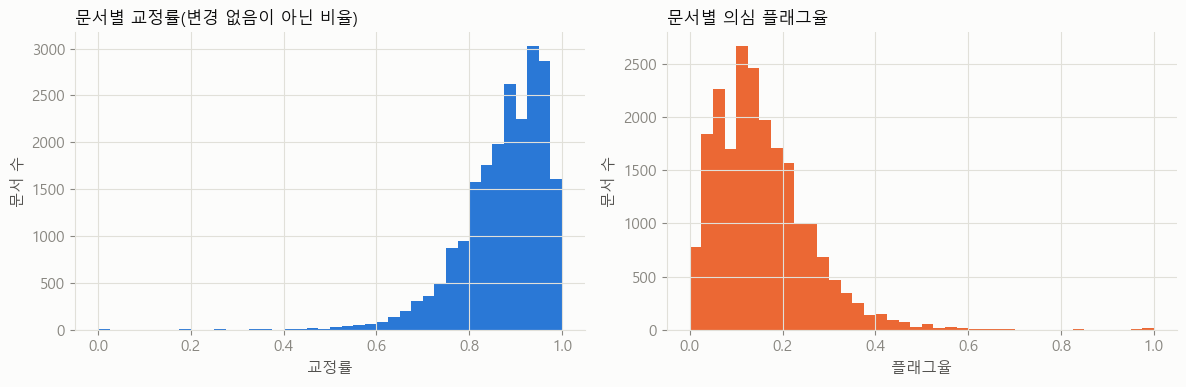


[플랫폼별 문서 단위 요약]


,문서수,문서당_발화수_중앙값,교정률_중앙값,플래그율_중앙값
publisher,,,,
심심이,15336,32.0,0.900,0.115
카카오톡,5999,33.0,0.861,0.205



[플랫폼 x 대화 길이 층별 문서 수]  (기준 미만 40개인 층: 0개)


,publisher,길이구간,문서 수
0,심심이,짧은 대화,6492
1,심심이,중간,4214
2,심심이,긴 대화,4630
3,카카오톡,짧은 대화,2056
4,카카오톡,중간,1999
5,카카오톡,긴 대화,1944


주제(topic) 종류 66개, 문서 40개 미만인 주제 39개 → 주제까지 함께 층화하면 작은 층이 생김


In [34]:
# 6.3 문서별 교정률·플래그율의 편차와 층화 가능성
vq = q.loc[q["valid"], ["doc_id", "form", "changed", "edit_type", "len_f", "n_flags"]].copy()
vq["flagged"] = vq["n_flags"] > 0
doc_stats = vq.groupby("doc_id").agg(발화수=("form", "size"), 교정률=("changed", "mean"), 철자단어변경률=("edit_type", lambda s: (s == 3).mean()),
                                    플래그율=("flagged", "mean"), 평균길이=("len_f", "mean"))
meta = df.drop_duplicates("doc_id").set_index("doc_id")[["publisher", "topic", "relation"]]
doc_stats = doc_stats.join(meta)

print("[문서 단위 지표의 분위수 - 문서 간 편차가 크면 분할 뒤 세 집합의 분포가 어긋날 수 있습니다]")
display(doc_stats[["발화수", "교정률", "철자단어변경률", "플래그율", "평균길이"]].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(doc_stats["교정률"], bins=40, color=CAT[0]); axes[0].set_title("문서별 교정률(변경 없음이 아닌 비율)", loc="left", fontsize=12, color=INK)
axes[0].set_xlabel("교정률"); axes[0].set_ylabel("문서 수")
axes[1].hist(doc_stats["플래그율"], bins=40, color=CAT[1]); axes[1].set_title("문서별 의심 플래그율", loc="left", fontsize=12, color=INK)
axes[1].set_xlabel("플래그율"); axes[1].set_ylabel("문서 수")
plt.tight_layout(); plt.show()

by_pub = doc_stats.groupby("publisher").agg(문서수=("발화수", "size"), 문서당_발화수_중앙값=("발화수", "median"), 교정률_중앙값=("교정률", "median"), 플래그율_중앙값=("플래그율", "median")).round(3)
print("\n[플랫폼별 문서 단위 요약]")
display(by_pub)

# 층화 가능성: 분할 3개에 5%씩 넣으려면 층마다 문서가 충분히 있어야 합니다
MIN_DOCS_PER_CELL = 40   # 검증·테스트가 각각 5%라면, 층당 최소 문서 수가 이 정도는 되어야 층별 비율이 의미 있음(초기 기준)
strata = doc_stats.assign(길이구간=pd.qcut(doc_stats["발화수"], 3, labels=["짧은 대화", "중간", "긴 대화"], duplicates="drop"))
cells = strata.groupby(["publisher", "길이구간"], observed=True).size().rename("문서 수").reset_index()
print(f"\n[플랫폼 x 대화 길이 층별 문서 수]  (기준 미만 {MIN_DOCS_PER_CELL}개인 층: {int((cells['문서 수'] < MIN_DOCS_PER_CELL).sum())}개)")
display(cells)
topic_docs = doc_stats["topic"].value_counts()
print(f"주제(topic) 종류 {len(topic_docs)}개, 문서 {MIN_DOCS_PER_CELL}개 미만인 주제 {int((topic_docs < MIN_DOCS_PER_CELL).sum())}개 → 주제까지 함께 층화하면 작은 층이 생김")

### 6.4 분할 기준을 정할 때 위 수치를 읽는 방법

아래는 결과를 어떻게 해석해서 어떤 결정으로 이어 갈지의 **판단 틀**입니다. 숫자 자체는 위 셀의 출력을 보고 채우세요. 측정하지 않은 내용을 미리 결론짓지 않습니다.

| 확인 결과 | 해석 | 이어서 할 결정 |
|---|---|---|
| 6.1의 기댓값이 높음(문서당 발화 수가 많을수록 높아짐) | 발화 단위 분할은 같은 대화의 문맥·말투가 평가로 새어 들어감 | 문서(대화) 단위로 분할 |
| 6.2에서 **긴** 문장의 문서 간 반복이 거의 없음 | 문서 단위 분할만으로 대화 복제 누수는 크지 않음 | 별도 묶음 처리 없이 문서 단위 분할 |
| 6.2에서 긴 문장으로 연결된 문서 묶음이 있음 | 같은 대화가 복제됐을 가능성 | 연결된 묶음 전체를 같은 집합에 배정 |
| 6.2에서 **짧은** 상투 표현(ㅋㅋ, ㅇㅇ 등)만 문서 간 반복 | 문서 단위로 나눠도 남는 불가피한 중복 | 제거하지 않고, 평가 시 반복 표현이 점수에 미치는 영향을 별도로 보고 |
| 6.3에서 문서 간 교정률·플래그율 편차가 큼 | 무작위 문서 분할만으로는 세 집합 분포가 어긋날 수 있음 | 교정률 구간 등으로 층화하거나, 분할 후 세 집합의 분포를 비교해서 확인 |
| 6.3에서 층별 문서 수가 기준 미만인 층이 있음 | 그 층까지 세분화하면 검증·테스트 표본이 불안정 | 층화 기준을 줄이고(예: 플랫폼만) 나머지는 분할 후 분포 비교로 점검 |

**분할 전 순서(권장)**: 제외 후보 규칙 확정(5.6) → 문서 단위로 배정 → 발화 단위 제외는 각 집합 안에서 적용 → 문서의 소속은 제외 때문에 바뀌지 않음. 이 순서를 지키면 제외 작업이 분할을 흔들지 않습니다.

**이 EDA로 확인할 수 없는 것**: 원본 메타데이터의 대화 날짜(`date`)나 화자 ID의 문서 간 중복 여부는 이 노트북에서 파싱하지 않았으므로 **확인 불가**입니다. 같은 화자가 여러 대화에 등장한다면 화자 단위 누수도 가능하지만, 그 정도는 이 노트북에서 측정하지 않았습니다.

## 7. 다음으로 해볼 만한 분석

- **화자별 오류 패턴**: 같은 speaker_id가 반복하는 오타/말버릇을 화자 단위로 모아 보기
- **어휘/N-그램 분석**: corrected_form 기준 형태소 분석기(예: KoNLPy, Kiwi)로 토큰화 후 빈도, 신조어 사전과 비교
- **챗봇(심심이) vs 사람 대화(카카오톡) 비교**: 같은 오류 유형이라도 플랫폼별로 분포가 다른지
- **규칙기반 맞춤법 검사기(baseline) 결과와 비교**: 이 노트북에서 계산한 유사도 분포와 나란히 놓고 생성형 모델의 개선폭 가늠
- **이상치 점검**: len_form이 0이거나 매우 큰 발화, corrected_form이 비어있는 경우 직접 샘플링해서 확인

### 참고: 학습용 train/valid/test 분할은 반드시 문서(document) 단위로

발화(utterance) 단위로 무작위 분할하면 같은 대화의 문맥·화자 말투가 train/test에 걸쳐 섞여 성능이 과대평가됩니다. 아래는 문서 단위 분할 예시 코드입니다.

```python
import numpy as np

doc_ids = df["doc_id"].unique()
rng = np.random.default_rng(42)
rng.shuffle(doc_ids)

n = len(doc_ids)
train_ids = set(doc_ids[: int(n * 0.8)])
valid_ids = set(doc_ids[int(n * 0.8): int(n * 0.9)])
test_ids  = set(doc_ids[int(n * 0.9):])

train_df = df[df["doc_id"].isin(train_ids)]
valid_df = df[df["doc_id"].isin(valid_ids)]
test_df  = df[df["doc_id"].isin(test_ids)]

print(len(train_df), len(valid_df), len(test_df))
```